<a href="https://colab.research.google.com/github/erralorenzo/Analysis_Collabs/blob/main/Course_Py_Mat.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Matlab

## Ejercicio 3


A partir de la tabla de datos adjunta, crear un sistema que sea capaz de predecir la temperatura promedio de la tierra para un año determinado.
Probar diversas  épocas y optimizadores  hasta alcanzar el mejor modelo para una red de una sola neurona.


In [ ]:
# -------------- Importa
import pandas as pd
import tensorflow as tf
from tensorflow import keras
import numpy as np

In [ ]:
#-------------- Modelo
# 1.Arquitectura modelo
model = tf.keras.Sequential(keras.layers.Dense(units=1, input_shape=[1]))
#units es cantidad de neuronas por capa
#input_shape cantidad de neuronas en primer capa

# 2.Compilacion del modelo
model.compile(optimizer=tf.keras.optimizers.Adam(0.1), loss="mean_squared_error")

entradas= np.array([1,10,100,1000,10000])
salidas = np.array([200,2000,20000,200000,2000000])
model.fit(entradas,salidas,epochs=1000, verbose=False)
model.predict([100])

array([[8800.61]], dtype=float32)

In [ ]:
df=pd.read_csv('clima.csv')
anios = list(df.year)
temperaturas= list(df.temp)

model = tf.keras.Sequential(keras.layers.Dense(units=1, input_shape=[1]))
model.compile(optimizer=tf.keras.optimizers.Adam(0.1), loss="mean_squared_error")
modeloclima = model.fit(anios,temperaturas, epochs=200, verbose=False) # quitar spam de entrenamiento
# valor = menu()

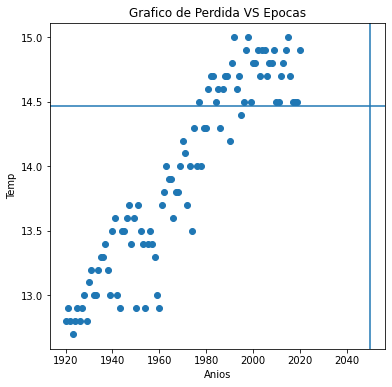

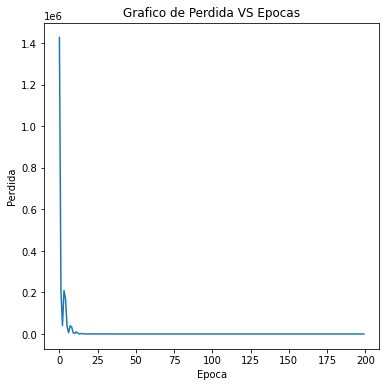

In [ ]:
year = 2050
prediccion = model.predict([year])
predic = prediccion[0][0]
# print(*prediccion[0])

#grafico para ver la correcion en las distintas epocas
import matplotlib.pyplot as plt
plt.figure(figsize=(6 , 6))
plt.xlabel("Anios")
plt.ylabel("Temp")
plt.title('Grafico de Perdida VS Epocas')
plt.scatter(anios,temperaturas)
plt.axvline(x=year)
plt.axhline(y=predic)
plt.show()

plt.figure(figsize=(6 , 6))
plt.xlabel("Epoca")
plt.ylabel("Perdida")
plt.title('Grafico de Perdida VS Epocas')
plt.plot(modeloclima.history['loss'])
plt.show( )

In [ ]:
%load_ext rpy2.ipython


In [ ]:
%%R
# install.packages('vegan')
install.packages('ade4')

In [ ]:
%%R
seq(1:10)

 [1]  1  2  3  4  5  6  7  8  9 10


In [ ]:
%%R
# r imports …
library(readr)
library(dplyr)
# library(phyloseq)

library(vegan)
library(ade4)
# library(ggplot2)


# plot(x,x)
# install.packages('SDMTools')
# library(SDMTools)

# https://fukamilab.github.io/BIO202/06-C-matrix-comparison.html#matrix_comparisons
# https://rdrr.io/cran/SDMTools/man/compare.matrix.html
#create some simple objects of class 'asc'
# tasc = (matrix(rep(x=0:1, times=20),nr=6))
N = 4
M= 20
tasc = matrix( rnorm(N*M,mean=0,sd=4), N, M)
print(tasc)

# Calculate distance using Bray-Curtis
DM16s <- distance(tasc,"bray")
# DMco1 <- distance(merged_CO1, "bray")
#modify the asc objects so that they are slightly different
# tasc1 = tasc + runif(n = 20, min = -1, max = 1)
# tasc2 = tasc + rnorm(n = 20, mean = 1, sd = 1)

#create some images
#basic plot showing the density of data combinations shared
#by the two matrices
# compare.matrix(tasc1,tasc2,20)

#same as previous but with data partioned amoung more bins
# compare.matrix(tasc1,tasc2,50)

#same as previous but altering the number of contour levels
#and adding more graphical functions
# compare.matrix(tasc1,tasc2,50,nlevels=5, xlab='asc1',ylab='asc2',main='Comparison between asc and asc2', bg="grey")
# mysvd<-svd(mymatrix)


# newmatrix<-mysvd$u %*% diag(mysvd$d) %*% t(mysvd$v)

In [ ]:
%%R
# https://www.rdocumentation.org/packages/SDMTools/versions/1.1-221/topics/compare.matrix
install.packages('SDMTools')
#create some simple objects of class 'asc'
# tasc = (matrix(rep(x=1:10, times=1000),nr=100))
N = 4
M= 20
tasc = matrix( rnorm(N*M,mean=0,sd=4), N, M)
print(tasc)
#modify the asc objects so that they are slightly different
tasc1 = tasc + runif(n = 20, min = -1, max = 1)
tasc2 = tasc + rnorm(n = 20, mean = 1, sd = 1)

#create some images
#basic plot showing the density of data combinations shared
#by the two matrices
compare.matrix(tasc1,tasc2,20)

#same as previous but with data partioned amoung more bins
compare.matrix(tasc1,tasc2,50)

#same as previous but altering the number of contour levels
#and adding more graphical functions
compare.matrix(tasc1,tasc2,50,nlevels=5, xlab='asc1',ylab='asc2',
  main='Comparison between asc and asc2', bg="grey")


# Extra

In [ ]:
#%%
!pip install folium
# conda install folium -c conda-forge
!pip install geopandas

     |████████████████████████████████| 1.0 MB 32.3 MB/s 
     |████████████████████████████████| 6.3 MB 33.0 MB/s 
     |████████████████████████████████| 15.4 MB 20.8 MB/s 


In [ ]:
!pip install geocoder

     |████████████████████████████████| 98 kB 6.1 MB/s 


In [ ]:
# heat map over time
import folium
from folium import plugins
import folium.plugins as plugins
import ipywidgets
import geocoder
import geopy
import numpy as np
import pandas as pd
from vega_datasets import data as vds
# data
# take note of data format needed for heat map with time (using plugins.HeatMapWithTime?)
heatmap_time_data = (np.random.random((100,20,2)) + np.array([[39, -98]])).tolist()
print(heatmap_time_data)
# dates
heatmap_time_dates = [d.strftime('%Y-%m-%d') for d in pd.date_range('20160101', periods=len(heatmap_time_data))]

# map
map_heatmap_time = folium.Map([39, -98], tiles='CartoDB Dark_Matter', zoom_start=6)

# heatmap plugin
heatmap_time_plugin = plugins.HeatMapWithTime(heatmap_time_data, index=heatmap_time_dates,auto_play=True,max_opacity=0.8)

# add heatmap plugin to map
heatmap_time_plugin.add_to(map_heatmap_time)

# display map
map_heatmap_time

In [ ]:
import folium
import folium.plugins as plugins
import numpy as np

np.random.seed(3141592)
initial_data = np.random.normal(size=(100, 2)) * np.array([[1, 1]]) + np.array(
    [[48, 5]]
)

move_data = np.random.normal(size=(100, 2)) * 0.01

data = [(initial_data + move_data * i).tolist() for i in range(100)]

weight = 1  # default value
for time_entry in data:
    for row in time_entry:
        row.append(weight)
m = folium.Map([48.0, 5.0], tiles="stamentoner", zoom_start=6)

hm = plugins.HeatMapWithTime(data)

hm.add_to(m)

m

In [ ]:
import pandas as pd
import folium
from folium import plugins

data = [[41.895278,12.482222,2873494.0,20.243001,20414,7.104243],
        [41.883850,12.333330,3916.0,0.835251,4,1.021450],
        [41.854241,12.567000,22263.0,1.132390,35,1.572115],
        [41.902147,12.590388,19505.0,0.839181,37,1.896950],
        [41.994240,12.48520,16239.0,1.383981,25,1.539504]]

df = pd.DataFrame(columns=['latitude','longitude','population','radius','count','normalized'],data=data)

middle_lat = df['latitude'].median()
middle_lon = df['longitude'].median()
m = folium.Map(location=[middle_lat, middle_lon],tiles = "Stamen Terrain",zoom_start=11)

# convert to (n, 2) nd-array format for heatmap
points = df[['latitude', 'longitude', 'normalized']].dropna().values

# plot heatmap
plugins.HeatMap(points, radius=15).add_to(m)
m

In [ ]:
import random
import numpy

pointArrays = numpy.split(points, len(points))
radii = [5, 10, 15, 20, 25]

for point, radius in zip(pointArrays, radii):
    plugins.HeatMap(point, radius=radius).add_to(m)
m

# Unidad 12

### 12.2 BURB


In [ ]:
# -*- coding: utf-8 -*-
"""
Created on Sun Oct 31 19:23:00 2021

@author: loren
"""
#%% Ordenamiento por selección

def ord_seleccion(lista):
    """Ordena una lista de elementos según el método de selección.
       Pre: los elementos de la lista deben ser comparables.
       Post: la lista está ordenada."""

    # posición final del segmento a tratar
    n = len(lista) - 1

    # mientras haya al menos 2 elementos para ordenar
    while n > 0:
        # posición del mayor valor del segmento
        p = buscar_max(lista, 0, n)

        # intercambiar el valor que está en p con el valor que
        # está en la última posición del segmento
        lista[p], lista[n] = lista[n], lista[p]
        print("DEBUG: ", p, n, lista)

        # reducir el segmento en 1
        n = n - 1

    return lista

def buscar_max(lista, a, b):
    """Devuelve la posición del máximo elemento en un segmento de
       lista de elementos comparables.
       La lista no debe ser vacía.
       a y b son las posiciones inicial y final del segmento"""

    pos_max = a
    for i in range(a + 1, b + 1):
        if lista[i] > lista[pos_max]:
            pos_max = i
    return pos_max


#%%
# lista = [3, 2, -1, 5, 0, 2]
# ord_seleccion(lista)

#%% Ordenamiento por inserción

def ord_insercion(lista):
    """Ordena una lista de elementos según el método de inserción.
       Pre: los elementos de la lista deben ser comparables.
       Post: la lista está ordenada."""

    for i in range(len(lista) - 1):
        # Si el elemento de la posición i+1 está desordenado respecto
        # al de la posición i, reubicarlo dentro del segmento [0:i]
        if lista[i + 1] < lista[i]:
            reubicar(lista, i + 1)
        print("DEBUG: ", lista)

    return lista

def reubicar(lista, p):
    """Reubica al elemento que está en la posición p de la lista
       dentro del segmento [0:p-1].
       Pre: p tiene que ser una posicion válida de lista."""

    v = lista[p]

    # Recorrer el segmento [0:p-1] de derecha a izquierda hasta
    # encontrar la posición j tal que lista[j-1] <= v < lista[j].
    j = p
    while j > 0 and v < lista[j - 1]:
        # Desplazar los elementos hacia la derecha, dejando lugar
        # para insertar el elemento v donde corresponda.
        lista[j] = lista[j - 1]
        j -= 1

    lista[j] = v

#%%

def ord_burbujeo(lista):
        repeticion = len(lista)

        while repeticion > 0:
            for i in range(len(lista) - 1):
                # print(lista, repeticion)
                if lista[i + 1] < lista[i]:
                    lista[i],lista[i+1]=lista[i+1],lista[i]
                    # print(lista)
                # print(repeticion)
            repeticion -= 1
        return lista
#%%

def ejecutar(mensaje):
    print(mensaje)

if __name__ == "__main__":
    print('\nEjercicio 12.2 \n')
    lista_2 = [0, 9, 3, 8, 5, 3, 2, 4]
    print(ord_burbujeo(lista_2))
    ejecutar("\nSe ejecuto tu programa")



### 12.7 comparaciones_ordenamiento


In [ ]:
# -*- coding: utf-8 -*-
"""
Created on Tue Nov  2 15:42:09 2021

@author: loren
"""

#%% Seleccion
def ord_seleccion(lista):
    """Ordena una lista de elementos según el método de selección.
       Pre: los elementos de la lista deben ser comparables.
       Post: la lista está ordenada."""

    # posición final del segmento a tratar
    n = len(lista) - 1
    comparaciones = 0
    # mientras haya al menos 2 elementos para ordenar
    while n > 0:
        # posición del mayor valor del segmento
        comparaciones += n-0
        pos_maximo = buscar_max(lista, 0, n)

        # intercambiar el valor que está en p con el valor que
        # está en la última posición del segmento
        # print("DEBUG: ", pos_maximo, n, lista)
        lista[pos_maximo], lista[n] = lista[n], lista[pos_maximo]
        # print("DEBUG: ", pos_maximo, n, lista)

        # reducir el segmento en 1
        n = n - 1

    return comparaciones

def buscar_max(lista, a, b):
    """Devuelve la posición del máximo elemento en un segmento de
       lista de elementos comparables.
       La lista no debe ser vacía.
       a y b son las posiciones inicial y final del segmento"""

    pos_max = a
    for i in range(a + 1, b + 1):
        if lista[i] > lista[pos_max]:
            pos_max = i
    return pos_max


#%%

def ord_insercion(lista):
    """Ordena una lista de elementos según el método de inserción.
       Pre: los elementos de la lista deben ser comparables.
       Post: la lista está ordenada."""
    comparaciones = 0
    for i in range(len(lista) - 1):
        # Si el elemento de la posición i+1 está desordenado respecto
        # al de la posición i, reubicarlo dentro del segmento [0:i]
        # comparaciones += 1 # deberia ser asi o algo similar
        if lista[i + 1] < lista[i]:
            comparaciones+= len(lista[0:i+1]) # deberia ser asi o algo similar
            comparaciones += 2 # slack?


            reubicar(lista, i + 1)

        # print("DEBUG: ", lista)
    return comparaciones

def reubicar(lista, p):
    """Reubica al elemento que está en la posición p de la lista
       dentro del segmento [0:p-1].
       Pre: p tiene que ser una posicion válida de lista."""
    v = lista[p]

    # Recorrer el segmento [0:p-1] de derecha a izquierda hasta
    # encontrar la posición j tal que lista[j-1] <= v < lista[j].
    j = p
    while j > 0 and v < lista[j - 1]:
        # Desplazar los elementos hacia la derecha, dejando lugar
        # para insertar el elemento v donde corresponda.
        lista[j] = lista[j - 1]
        j -= 1

    lista[j] = v
    # return  v, comparaciones

#%%

def ord_burbujeo(lista):
       repeticion = len(lista)
       comparaciones = 0
       while repeticion > 0:
           for i in range(len(lista) - 1):
               # comparaciones+=1 # deberia ser asi
               if lista[i + 1] < lista[i]:
                   lista[i],lista[i+1]=lista[i+1],lista[i]
                   comparaciones+=1 # para que de como esta en slack
           repeticion -= 1
       return comparaciones



#%%
import random
import matplotlib.pyplot as plt
def generar_lista(N):
    return random.sample(range(1, 1000), N)


def experimento(N, k):
    selec = []
    inser = []
    bur = []

    for i in range(k):
        lista = generar_lista(N)
        selec.append(ord_seleccion(lista.copy()))
        inser.append(ord_insercion(lista.copy()))
        bur.append(ord_burbujeo(lista.copy()))

    return (sum(selec)/k,sum(inser)/k,sum(bur)/k)

# print(experimento(10,2))

def experimento_vectores(nmax):
    selec = []
    inser = []
    bur = []
    largos = []
    for i in range(nmax):
        # print(i+1)
        l = generar_lista(i)
        # print(l)
        largos.append(i)
        selec.append(ord_seleccion(l.copy()))
        inser.append(ord_insercion(l.copy()))
        bur.append(ord_burbujeo(l.copy()))
    plt.plot(largos, selec, label='Seleccin')
    plt.plot(largos, inser,linestyle="-.", label='Insercion')
    plt.plot(largos, bur,label='Burbujeo')
    plt.legend()
    plt.show()

#%%
def ejecutar(mensaje):
    print(mensaje)

if __name__ == "__main__":
    print('\nEjercicio 12.7 \n')
    print(experimento_vectores(10))
    ejecutar("\nSe ejecuto tu programa")

#%%

import timeit as tt
import numpy as np

tt.timeit('"-".join(str(n) for n in range(100))', number = 1)


listas = []
for N in range(1, 256):
    listas.append(generar_lista(N))

def experimento_timeit_seleccion(listas, num):
    """
    Realiza un experimento usando timeit para evaluar el método
    de selección para ordenamiento de listas
    con las listas pasadas como entrada
    y devuelve los tiempos de ejecución para cada lista
    en un vector.
    El parámetro 'listas' debe ser una lista de listas.
    El parámetro 'num' indica el número de veces que repite el ordenamiento para cada lista.
    """
    tiempos_seleccion = []

    global lista

    for lista in listas:

        # evalúo el método de selección
        # en una copia nueva para cada iteración
        tiempo_seleccion = tt.timeit('ord_seleccion(lista.copy())', number = num, globals = globals())

        # guardo el resultado
        tiempos_seleccion.append(tiempo_seleccion)

    # paso los tiempos a arrays
    tiempos_seleccion = np.array(tiempos_seleccion)

    return tiempos_seleccion

tiempos_seleccion = experimento_timeit_seleccion(listas, 100)
plt.plot(tiempos_seleccion)

### 12.8 time_ordenamiento

In [ ]:
# -*- coding: utf-8 -*-
"""
Created on Wed Nov  3 11:57:31 2021

@author: loren
"""

# -*- coding: utf-8 -*-
"""
Created on Tue Nov  2 15:42:09 2021

@author: loren
"""

#%% Seleccion
def ord_seleccion(lista):
    """Ordena una lista de elementos según el método de selección.
       Pre: los elementos de la lista deben ser comparables.
       Post: la lista está ordenada."""

    # posición final del segmento a tratar
    n = len(lista) - 1

    # mientras haya al menos 2 elementos para ordenar
    while n > 0:
        # posición del mayor valor del segmento

        pos_maximo = buscar_max(lista, 0, n)

        # intercambiar el valor que está en p con el valor que
        # está en la última posición del segmento
        lista[pos_maximo], lista[n] = lista[n], lista[pos_maximo]

        # reducir el segmento en 1
        n = n - 1

    return lista

def buscar_max(lista, a, b):
    """Devuelve la posición del máximo elemento en un segmento de
       lista de elementos comparables.
       La lista no debe ser vacía.
       a y b son las posiciones inicial y final del segmento"""
    pos_max = a
    for i in range(a + 1, b + 1):
        if lista[i] > lista[pos_max]:
            pos_max = i
    return pos_max


#%%

def ord_insercion(lista):
    """Ordena una lista de elementos según el método de inserción.
       Pre: los elementos de la lista deben ser comparables.
       Post: la lista está ordenada."""

    for i in range(len(lista) - 1):
        # Si el elemento de la posición i+1 está desordenado respecto
        # al de la posición i, reubicarlo dentro del segmento [0:i]
        # comparaciones += 1 # deberia ser asi o algo similar
        if lista[i + 1] < lista[i]:
            reubicar(lista, i + 1)
    return lista

def reubicar(lista, p):
    """Reubica al elemento que está en la posición p de la lista
       dentro del segmento [0:p-1].
       Pre: p tiene que ser una posicion válida de lista."""
    v = lista[p]

    # Recorrer el segmento [0:p-1] de derecha a izquierda hasta
    # encontrar la posición j tal que lista[j-1] <= v < lista[j].
    j = p
    while j > 0 and v < lista[j - 1]:
        # Desplazar los elementos hacia la derecha, dejando lugar
        # para insertar el elemento v donde corresponda.
        lista[j] = lista[j - 1]
        j -= 1
    lista[j] = v


#%%

def ord_burbujeo(lista):
       repeticion = len(lista)
       comparaciones = 0
       while repeticion > 0:
           for i in range(len(lista) - 1):
               # comparaciones+=1 # deberia ser asi
               if lista[i + 1] < lista[i]:
                   lista[i],lista[i+1]=lista[i+1],lista[i]
                   comparaciones+=1 # para que de como esta en slack
           repeticion -= 1
       return comparaciones



#%%
import timeit as tt
import random
import matplotlib.pyplot as plt
def generar_lista(N):
    return random.sample(range(1, 1000), N)


def generar_listas(Nmax):
    listas = []
    for i in range(Nmax):
        listas.append(generar_lista(i))
    return listas

def experimento_timeit(Nmax):
    selec = []
    inser = []
    bur = []
    largos = []
    listas = generar_listas(Nmax)
    for lista in listas:
        # print(i+1)
        largos.append(len(lista))
        # print(i)

        selec.append(tt.timeit('ord_seleccion(lista.copy())', number = 100, globals = globals()))
        inser.append(tt.timeit('ord_insercion(lista.copy())', number = 100, globals = globals()))
        bur.append(tt.timeit('ord_burbujeo(lista.copy())', number = 100, globals = globals()))

    plt.plot(largos, selec, label='Seleccin')
    plt.plot(largos, inser,linestyle="-.", label='Insercion')
    plt.plot(largos, bur,label='Burbujeo')
    plt.legend()
    plt.show()


#%%
def ejecutar(mensaje):
    print(mensaje)

if __name__ == "__main__":
    print('\nEjercicio 12.7 \n')
    print(experimento_timeit(100))
    ejecutar("\nSe ejecuto tu programa")

### 12.10 iris_seaborn

In [ ]:
# -*- coding: utf-8 -*-
"""
Created on Wed Nov  3 12:56:23 2021

@author: loren
"""


from sklearn.datasets import load_iris
iris_dataset = load_iris()
iris_dataframe = pd.DataFrame(iris_dataset['data'], columns = iris_dataset.feature_names)
import seaborn as sns

iris_dataframe['target'] = iris_dataset['target']
sns.pairplot(iris_dataframe,hue='target')


# Unidad 11

### 11.9 Larenga


In [ ]:
def pascal(n, k=0):

    def pascal_aux(n):
        if n == 0:
            return [1]
        else:
            pasc= [1]
            linea_previa = pascal_aux(n-1)

            # print(linea_previa)
            for i in range(len(linea_previa)-1):
                pasc.append(linea_previa[i]+linea_previa[i+1])
            pasc+=[1]
        return pasc

    res = pascal_aux(n)
    res= res[k]
    return res

### 11.11 BusqBin


In [ ]:
def bbinaria_rec(lista, e):
    res = None
    if len(lista) == 0:
        res = False
    elif len(lista) == 1:
        res = lista[0] == e
    else:
        medio = len(lista)//2
        if e < lista[medio]:
            return bbinaria_rec(lista[:medio], e)
        elif e >= lista[medio]:
            return bbinaria_rec(lista[medio:], e)

    return res

#%%

print(bbinaria_rec([1,2,3,5,6,7,8,9,10],10))

### 11.13 Hojas ISO

In [ ]:

def medidas_hoja_A(N):
    res = None

    def medidas_hoja_A_aux(N, lista,hoj):
        if N>0: #Donde hacemos la recursion
            lista[1] = hoja[1]//2
            lista.reverse()
            hoj += 1
            return medidas_hoja_A_aux(N-1,lista,hoj)
        elif N == 0:    # llegamos al final de la recursion
            return lista,hoj

    hoja= [841,1189] # defino la lista inical de valores AyL
    if N == 0:
        res =(841,1189)
    else:
        hoj = 0
        res,numerohoja = medidas_hoja_A_aux(N,hoja,hoj)

    print(f'Has elegido una hoja A{numerohoja} que tiene las siguiente especificaciones:')
    print('Ancho y Largo (mm)')
    return tuple(res)

#%%

def ejecutar(mensaje):
    print(mensaje)

if __name__ == "__main__":
    print('\nEjercicio 11.13 \n')
    print(medidas_hoja_A(4))
    ejecutar("\nSe ejecuto tu programa")

### 11.14 Alquiler

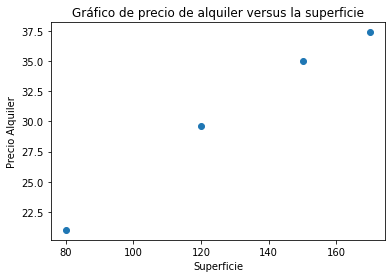

[ 0.55434783  0.69782609 -0.74130435 -0.51086957]
ECM: 0.4011956521739133


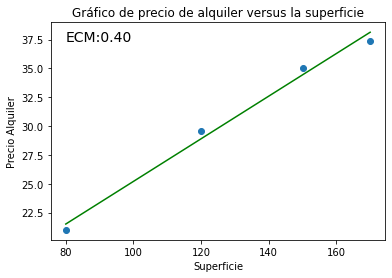

In [ ]:

import numpy as np
import matplotlib.pyplot as plt

superficie = np.array([150.0, 120.0, 170.0, 80.0])
alquiler = np.array([35.0, 29.6, 37.4, 21.0])

# N = 50
minx = min(superficie)
maxx = max(superficie)
# x = np.random.uniform(minx, maxx, N)
# r = np.random.normal(0, 25, N) # residuos simulados
# y = 1.3*x + r

g = plt.scatter(x = superficie, y = alquiler)
plt.title('Gráfico de precio de alquiler versus la superficie')
plt.xlabel('Superficie')
plt.ylabel('Precio Alquiler')
plt.show()

def ajuste_lineal_simple(x,y):
    a = sum(((x - x.mean())*(y-y.mean()))) / sum(((x-x.mean())**2))
    b = y.mean() - a*x.mean()
    return a, b

a, b = ajuste_lineal_simple(superficie, alquiler)

grilla_x = np.linspace(start = minx, stop = maxx, num = 1000)
grilla_y = grilla_x*a + b

g = plt.scatter(x = superficie, y = alquiler)
plt.plot(grilla_x, grilla_y, c = 'green')
plt.title('Gráfico de precio de alquiler versus la superficie')
plt.xlabel('Superficie')
plt.ylabel('Precio Alquiler')
errores = alquiler - (a*superficie + b)
ecm = (errores**2).mean()
print(errores)
print("ECM:", (errores**2).mean())
plt.text( min(superficie),max(alquiler), f'ECM:{ecm:.2f}', fontsize = 14)
plt.show()


# Unidad 10

In [ ]:
# _iter = obj.__iter__()        # Buscar el objeto iterador
# while True:
#     try:
#         x = _iter.__next__()  # Dame el siguiente item
#     except StopIteration:     # No hay más items
#         break
a = [1, 9, 4, 25, 16]
i = a.__iter__()
i.__next__()
i.__next__()
i.__next__()
i.__next__()
i.__next__()
# i.__next__()

16

### 10.2 Informe Final

In [ ]:

#%% CLASE 9
  import csv

  import formato_tabla
  import fileparse

  def leer_camion(filename):  # devuelve una lista de listas, uno por cada linea del csv
      from camion import Camion
      from lote import Lote
      '''
      Lee un archivo con el contenido de un camión
      y lo devuelve como un objeto Camion.
      '''
      with open(filename) as file:
          camiondicts = fileparse.parse_csv_67(file,
                                          select = ['nombre', 'cajones', 'precio'],
                                          types = [str, int, float])
      camion = [Lote(d['nombre'], d['cajones'], d['precio']) for d in camiondicts]
      return Camion(camion)

  def leer_precios(filename):   # devuelve in diccionario del tipo: k = nombre del producto,
      return dict(fileparse.parse_csv_67(filename, types = [str, float], has_headers = False))

  def hacer_informe(productos, precios):
      """"
      Recibe diccionario con los precios y productos y da una lista para imprimir informe
      """
      lista = []
      for producto in productos:
          lista.append((producto.nombre,int(producto.cajones),float(precios[producto.nombre]),
                        float(precios[producto.nombre]) - float(producto.precio)))
      return lista

  def imprimir_informe(data_informe, formateador):
      '''
      Imprime una tabla prolija desde una lista de tuplas
      con (nombre, cajones, precio, diferencia)
      '''
      formateador.encabezado(['Nombre', 'Cantidad', 'Precio', 'Cambio'])
      for nombre, cajones, precio, cambio in data_informe:
          rowdata = [nombre, str(cajones), f'{precio:0.2f}', f'{cambio:0.2f}']
          formateador.fila(rowdata)

  def informe_camion(archivo_camion, archivo_precios,fmt='txt'):
      '''
      Crea un informe por camion a partir de archivos camion y precio.
      '''

      camion = leer_camion(archivo_camion)

      with open(archivo_precios) as f:
          filas_precios = csv.reader(f)
          precios = leer_precios(filas_precios)

      # Obtener los datos para un informe
      data_informe = hacer_informe(camion, precios)

      # Imprimir
      formateador = formato_tabla.crear_formateador(fmt)
      imprimir_informe(data_informe, formateador)

  #%%
  def ejecutar(mensaje):
      print(mensaje)

  if __name__ == "__main__":
      print('\nEjercicio 9.7\n')
      # imprimir_informe()
      # informe_camion('../Data/camion.csv', '../Data/precios.csv')
      informe_camion('../Data/camion.csv', '../Data/precios.csv', fmt = 'csv')
      ejecutar("\nSe ejecuto tu programa")

### 10.14 / 10.3 Camion
DUDAS al imprimir un camion

In [ ]:
# -*- coding: utf-8 -*-

#%% 10.2

class Camion:

    def __init__(self, lotes):
        self.lotes = lotes

    def __iter__(self):
        return self.lotes.__iter__()

    def __contains__(self, nombre):
        return any(lote.nombre == nombre for lote in self.lotes)

    def __len__(self):
        return sum(1 for l in self.lotes)

    def __getitem__(self, number):
        if isinstance(number, slice):
            return Camion(self.lotes[number])
        else:
            return self.lotes[number]

    def __str__(self):
        res = (f" Camion con {len(self.lotes)} lotes:\n")
        # res = ""
        if len(self.lotes) != 0:
            for l in self.lotes:
                res+= f"Lote de {l.cajones} cajones de {l.nombre}, pagados a ${l.precio} cada uno.\n"
        else:
            res+= ''+str(self.lotes)
        return res

    def __repr__(self) :
        # return f'{type(self).__name__}(Lote({self.lotes.cajones},{self.lotes.nombre},{self.lotes.precio}))'
        res=''
        if len(self.lotes) > 1:
            for l in self.lotes:
                res+= f"Lote({l.cajones},{l.nombre},{l.precio})"
        else:
            res+= ''+str(self.lotes)
            # res+= f"Lote({l.cajones},{l.nombre},{l.precio})"
        return res


    def precio_total(self):
        return sum(l.costo() for l in self.lotes)

    def contar_cajones(self):
        from collections import Counter
        cantidad_total = Counter()
        for l in self.lotes:
            cantidad_total[l.nombre] += l.cajones
        return cantidad_total



#%%
import informe_final
# from informe_final import leer_camion.
# informe_final.leer_camion('../Data/camion.csv')
camion = informe_final.leer_camion('../Data/camion.csv')
print('Naranja' in camion)
print(len(camion))
print(camion[0:2])
print(camion.precio_total())

# camion


### 10.7 Vigilante

In [ ]:
# -*- coding: utf-8 -*-

def vigilar(archivo):
    f = open(archivo)
    # f.seek(0, os.SEEK_END)
    while True:
        line = f.readline()
        if line != '':
            yield line
        else:
            break

 #%%x`
def ejecutar(mensaje):
    print(mensaje)

if __name__ == "__main__":
    print('\nEjercicio 10.7\n')

    import informe_final

    camion = informe_final.leer_camion ('../Data/camion.csv')

    for line in vigilar('../Data/mercadolog.csv'):
        fields = line.split(',')
        nombre = fields[0].strip('"')
        precio = float(fields[1])
        volumen = int(fields[2])

        if nombre in camion:
            print(f'{nombre:>10s} {precio:>10.2f} {volumen:>10d}')

    ejecutar("\nSe ejecuto tu programa")


### 10.15 Ticker

In [ ]:
# -*- coding: utf-8 -*-
"""
Created on Mon Oct 18 12:02:35 2021

@author: loren
"""


from vigilante import vigilar
import csv

# Parsea como csv
# def parsear_datos(lines):
#     rows = csv.reader(lines)
#     return rows

# Parsea como csv y elige columnas
def elegir_columnas(rows, indices):
    for row in rows:
        yield [row[index] for index in indices]

# def parsear_datos(lines):
#     rows = csv.reader(lines)
#     rows = elegir_columnas(rows, [0, 2])
#     return rows

# Parsea y genera un diccionario
def cambiar_tipo(rows, types):
    for row in rows:
        yield [func(val) for func, val in zip(types, row)]

def hace_dicts(rows, headers):
    for row in rows:
        yield dict(zip(headers, row))

def parsear_datos(lines):
    rows = csv.reader(lines)
    rows = elegir_columnas(rows, [0, 1, 2])
    rows = cambiar_tipo(rows, [str, float, int])
    rows = hace_dicts(rows, ['nombre', 'precio', 'volumen'])
    return rows


# Filtrando Datos
def filtrar_datos(rows, nombres):
    for row in rows:
        if row['nombre'] in nombres:
            yield row

def imprimir_informe(data_informe, formateador):
    '''
    Imprime una tabla prolija desde una lista de tuplas
    con (nombre, cajones, precio, diferencia)
    '''
    # print(data_informe)
    formateador.encabezado(['Nombre', 'Precio', 'Volumen'])
    for nombre, precio, volumen in data_informe:
        # print(nombre,precio,volumen)
        rowdata = [nombre, f'{precio:0.2f}', f'{volumen:0.2f}']
        formateador.fila(rowdata)


def ticker(archivo_camion,archivo_mercado, fmt='txt', has_headers=False):
    '''
    Crea un informe por camion a partir de archivos camion y precio.
    '''
    # from formato_tabla import crear_formateador
    import formato_tabla
    import informe_final
    camion = informe_final.leer_camion(archivo_camion)
    rows = parsear_datos(vigilar(archivo_mercado))
    rows = filtrar_datos(rows, camion)
    sumatoria = []
    if has_headers:
        encabezados = next(rows)
    for row in rows:
        sumatoria.append((row['nombre'],float(row['precio']),int(row['volumen'])))

    # Imprimir
    formateador = formato_tabla.crear_formateador(fmt)
    imprimir_informe(sumatoria, formateador)

#%%

#%%
def ejecutar(mensaje):
    print(mensaje)

if __name__ == "__main__":
    print('\nEjercicio 10.15\n')
    # imprimir_informe()
    # informe_camion('../Data/camion.csv', '../Data/precios.csv')
    ticker('../Data/camion.csv','../Data/mercadolog.csv', fmt = 'txt', has_headers=False)
    ejecutar("\nSe ejecuto tu programa")



# Unidad 9

### Ejercicio 9.1: Objetos como estructura de datos

In [ ]:
class Lote:
    def __init__(self, nombre, cajones, precio):
        # Todo dato guardado en `self` es propio de esa instancia
        self.nombre = nombre
        self.cajones = cajones
        self.precio = precio

a = Lote('Pera', 100, 490.10)
b = Lote('Manzana', 50, 122.34)
c = Lote('Naranja', 75, 91.75)
lotes = [a, b, c]
for c in lotes:
     print(f'{c.nombre:>10s} {c.cajones:>10d} {c.precio:>10.2f}')


      Pera        100     490.10
   Manzana         50     122.34
   Naranja         75      91.75


### Ejercicio 9.2: Agregá algunos métodos

In [ ]:
class Lote:
    def __init__(self, nombre, cajones, precio):
        # Todo dato guardado en `self` es propio de esa instancia
        self.nombre = nombre
        self.cajones = cajones
        self.precio = precio
    def costo(self):
        return self.cajones * self.precio

    def vender(self,venta):
        self.cajones-= venta

In [ ]:
s = Lote('Pera', 100, 490.10)
s.costo()
s.vender(25)
s.cajones
s.costo()


36757.5

### Ejercicio 9.8: Lista de instancias

In [ ]:

#%% CLASE 9
import csv
import sys
sys.path.insert(0, '../Clase07')
import fileparse
# from fileparse import parse_csv
from fileparse import parse_csv_67
from lote import Lote
import formato_tabla
import csv


def leer_camion(filename):  # devuelve una lista de listas, uno por cada linea del csv
    camion_dicts = parse_csv_67(filename, select = ['nombre', 'cajones', 'precio'], types = [str, int, float])
    camion = [Lote(d['nombre'], d['cajones'], d['precio']) for d in camion_dicts]
    return camion


def leer_precios(filename):   # devuelve in diccionario del tipo: k = nombre del producto,
    return dict(parse_csv_67(filename, types = [str, float], has_headers = False))

def hacer_informe(productos, precios):
    """"
    Recibe diccionario con los precios y productos y da una lista para imprimir informe
    """
    lista = []
    for producto in productos:
        lista.append((producto.nombre,int(producto.cajones),float(precios[producto.nombre]),
                      float(precios[producto.nombre]) - float(producto.precio)))
    return lista

def imprimir_informe(data_informe, formateador):
    '''
    Imprime una tabla prolija desde una lista de tuplas
    con (nombre, cajones, precio, diferencia)
    '''
    # formatero = formato_tabla.FormatoTablaHTML()
    formateador.encabezado(['Nombre', 'Cantidad', 'Precio', 'Cambio'])
    for nombre, cajones, precio, cambio in data_informe:
        rowdata = [nombre, str(cajones), f'{precio:0.2f}', f'{cambio:0.2f}']
        formateador.fila(rowdata)

def informe_camion(archivo_camion, archivo_precios,fmt='txt'):
    '''
    Crea un informe por camion a partir de archivos camion y precio.
    '''
    # Leer archivos con datos
    with open(archivo_camion) as f:
        filas_camion = csv.reader(f)
        camion = leer_camion(filas_camion)

    with open(archivo_precios) as f:
        filas_precios = csv.reader(f)
        precios = leer_precios(filas_precios)

    # Obtener los datos para un informe
    data_informe = hacer_informe(camion, precios)

    # Imprimir
    # formateador = formato_tabla.FormatoTablaTXT()
    formateador = formato_tabla.crear_formateador(fmt)
    imprimir_informe(data_informe, formateador)

#%%
def ejecutar(mensaje):
    print(mensaje)

if __name__ == "__main__":
    print('\nEjercicio 9.7\n')
    # imprimir_informe()
    # informe_camion('../Data/camion.csv', '../Data/precios.csv')
    informe_camion('../Data/camion.csv', '../Data/precios.csv', fmt = 'html')
    ejecutar("\nSe ejecuto tu programa")



### 9.9 Mejor salida para objetos

In [ ]:
class Lote:
    def __init__(self, nombre, cajones, precio):
        # Todo dato guardado en `self` es propio de esa instancia
        self.nombre = nombre
        self.cajones = cajones
        self.precio = precio
    def __repr__(self):
        return f'\nDe la {self.nombre} hay {self.cajones} cajones y tienen un precio de {self.precio}'
    def costo(self):
        return self.cajones * self.precio

    def vender(self,venta):
        self.cajones-= venta



#%% 9.3

import sys
sys.path.insert(0, '../Clase07')
import fileparse


with open('../Data/camion.csv') as lineas:
    camion_dicts = fileparse.parse_csv_67(lineas, select = ['nombre', 'cajones', 'precio'], types = [str, int, float])

camion = [Lote(d['nombre'], d['cajones'], d['precio']) for d in camion_dicts]
print(camion)


### 9.11 Canguros Buenos

In [ ]:
#%% 9.11
class Canguro:
    def __init__(self,nombre,contenido=None):
        # Todo dato guardado en `self` es propio de esa instancia
        if contenido is None:
            contenido = []
        self.nombre = nombre
        self.contenido_marsupio = contenido

    def meter_en_marsupio(self,marsup):
        self.contenido_marsupio.append(marsup)

    def __str__(self):
        res = f'El canguro {self.nombre} tiene en su marsupio:\n '
        if len(self.contenido_marsupio) != 0:
            for i in self.contenido_marsupio:
                res+= f'{object.__str__(i)}\n'
        return res

#%%
madre_canguro = Canguro('Madre')
cangurito = Canguro('gurito')
madre_canguro.meter_en_marsupio('billetera')
madre_canguro.meter_en_marsupio('llaves del auto')
madre_canguro.meter_en_marsupio(cangurito)
print(madre_canguro)

### 9.12 Torre Control

In [ ]:
class TorreDeControl:
    '''Representa a una cola, con operaciones de encolar y desencolar.
    El primero en ser encolado es tambien el primero en ser desencolado.
    '''

    def __init__(self):
        '''Crea una cola vacia.'''
        self.arribos = []
        self.partidas = []

    def nuevo_arribo(self, x):
        '''Encola a arribos.'''
        self.arribos.append(x)

    def nueva_partida(self, x):
        '''Encola a partidas.'''
        self.partidas.append(x)

    def asignar_pista(self):
        '''Elimina el primer elemento de la cola y devuelve su valor.
        Si la cola esta vacia, levanta ValueError.'''
        if self.esta_vacia():
            print('No hay vuelos en espera.')

        if len(self.arribos) > 0:
            print(f'El vuelo {self.arribos[0]} aterrizó con éxito.')
            res = self.arribos.pop(0)
            return res
        elif len(self.partidas) > 0:
            print(f'El vuelo {self.partidas[0]} despegó con éxito.')
            res = self.partidas.pop(0)
            return res



    def esta_vacia(self):
        '''Devuelve
        True si la cola esta vacia,False si no.'''
        return len(self.arribos) == 0 and len(self.partidas) == 0

    def ver_estado(self):
        res = "Vuelos esperando para aterrizar: <"
        res += ", ".join(self.arribos)
        res += ">\n"
        res += "Vuelos esperando para despegar: <"
        res += ", ".join(self.partidas)
        res += ">"
        print(res)


torre = TorreDeControl()
torre.nuevo_arribo('AR156')
torre.nueva_partida('KLM1267')
torre.nuevo_arribo('AR32')
torre.ver_estado()
# Vuelos esperando para aterrizar: AR156, AR32
# Vuelos esperando para despegar: KLM1267
# El vuelo AR156 aterrizó con éxito.
# El vuelo AR32 aterrizó con éxito.
# El vuelo KLM1267 despegó con éxito.
# No hay vuelos en espera.
torre.asignar_pista()
# torre.ver_estado()

torre.asignar_pista()
# torre.ver_estado()

torre.asignar_pista()
# torre.ver_estado()

torre.asignar_pista()
# torre.ver_estado()


Vuelos esperando para aterrizar: <AR156, AR32>
Vuelos esperando para despegar: <KLM1267>
El vuelo AR156 aterrizó con éxito.
El vuelo AR32 aterrizó con éxito.
El vuelo KLM1267 despegó con éxito.
No hay vuelos en espera.


# Unidad 8

In [ ]:
import datetime
print('='*20)

fecha_hora = datetime.datetime.now()
print(fecha_hora)
print('='*20)

fecha = datetime.date.today()
print(fecha)
print('='*20)

d = datetime.date(2019, 4, 13)
print(d)
print('='*20)

from datetime import date
timestamp = date.fromtimestamp(1326244364)
print('Fecha =', timestamp)
print('='*20)

from datetime import date
hoy = date.today()
print('Año actual:', hoy.year)
print('Mes actual:', hoy.month)
print('Día actual:', hoy.day)
print('Día de la semana:', hoy.weekday())
print('='*20)

from datetime import time
a = time(11, 34, 56)
print('hour =', a.hour)
print('minute =', a.minute)
print('second =', a.second)
print('microsecond =', a.microsecond)
print('='*20)

from datetime import datetime
a = datetime(2021, 4, 21, 6, 53, 31, 342260)
print('año =', a.year)
print('mes =', a.month)
print('día =', a.day)
print('hora =', a.hour)
print('minuto =', a.minute)
print('timestamp =', a.timestamp())
print('='*20)

from datetime import timedelta
t = timedelta(days = 1, hours = 2, seconds = 30, microseconds = 100000)
print('segundos totales =', t.total_seconds())
print('='*20)

from datetime import datetime

now = datetime.now()
t = now.strftime('%H:%M:%S')
print('hora:', t)
s1 = now.strftime('%m/%d/%Y, %H:%M:%S')
# en formato mm/dd/YY H:M:S
print('s1:', s1)
s2 = now.strftime('%d/%m/%Y, %H:%M:%S')
# en formato dd/mm/YY H:M:S
print('s2:', s2)
print('='*20)

from datetime import datetime
cadena_con_fecha= '21 September, 2021'
print('date_string =', cadena_con_fecha)
date_object = datetime.strptime(cadena_con_fecha, '%d %B, %Y')
print('date_object =', date_object)
print('='*20)



2021-10-02 22:24:43.799307
2021-10-02
2019-04-13
Fecha = 2012-01-11
Año actual: 2021
Mes actual: 10
Día actual: 2
Día de la semana: 5
hour = 11
minute = 34
second = 56
microsecond = 0
año = 2021
mes = 4
día = 21
hora = 6
minuto = 53
timestamp = 1618988011.34226
segundos totales = 93630.1
hora: 22:24:43
s1: 10/02/2021, 22:24:43
s2: 02/10/2021, 22:24:43
date_string = 21 September, 2021
date_object = 2021-09-21 00:00:00


### Ejercicio 8.1: Segundos vividos
Escribí una función llamada vida_en_segundos(fecha_nac) a la que le pasás tu fecha de nacimiento y te devuelve la cantidad de segundos que viviste (asumiendo que naciste a las 00:00hs de tu fecha de nacimiento). La función debe tomar como entrada una cadena en formato 'dd/mm/AAAA' (día, mes, año con 2, 2 y 4 dígitos, separados con barras normales) y devolver un float.

Guardá este código en el archivo vida.py.

In [ ]:
import datetime
fecha_hora = datetime.datetime.now()
print(fecha_hora)
fecha = datetime.date.today()
print(fecha)

2021-10-02 22:31:08.383736
2021-10-02


### 8.1

In [ ]:
def vida_en_segundos(fecha_nac):
    #transformo entrada
    from datetime import datetime
    date_object = datetime.strptime(fecha_nac, '%d/%m/%Y')

    #Dia de hoy
    import datetime
    fecha_hora = datetime.datetime.now()

    # Calculo de la diferencia
    dif = fecha_hora - date_object
    return float(dif.total_seconds())

vida_en_segundos('11/08/1994')

856651166.591951

In [ ]:
import os
os.getcwd()
# os.chdir('Data')              # entro en ../Data
# print(os.getcwd())
# os.chdir('..')

# Ver tu directorio
print('Tu directorio:', os.getcwd())

# listar lo que hay dentro
os.listdir(os.getcwd())         # lista lo que hay en el directorio
print(os.listdir(os.getcwd()))

# Crear directorios
os.mkdir('test')          # creo el directorio test
os.mkdir(os.path.join('test', 'carpeta'))  # creo el subdirectorio carpeta dentro de test
os.listdir('test')

# Cambiar nombre directorio
os.chdir('test')                     # entro en el directorio test
print('Que hay en tu direc',os.listdir())
os.rename('carpeta','carpeta_nueva') # cambio el nombre de carpeta
os.listdir()


Tu directorio: /content/test
['carpeta_nueva']
Que hay en tu direc ['carpeta']


['carpeta_nueva']

In [ ]:
# Cambiar la fecha de un archivo
import os
import datetime
import time

camino = '../Clase06/rebotes.py'

stats_archivo = os.stat(camino)
print(time.ctime(stats_archivo.st_atime))

fecha_acceso = datetime.datetime(year = 2017, month = 9, day = 21, hour = 19, minute =51, second = 0)
fecha_modifi = datetime.datetime(year = 2012, month = 9, day = 24, hour = 12, minute =9, second = 24)

ts_acceso = fecha_acceso.timestamp()
ts_modifi = fecha_modifi.timestamp()
os.utime(camino, (ts_acceso, ts_modifi))

stats_archivo = os.stat(camino)
print(time.ctime(stats_archivo.st_atime))

### 8.5 listar_imgs


In [ ]:
def archivos_png(ubicacion):
    lista = []
    import os
    for root, dirs, files in os.walk(ubicacion):
       for name in files:
           if name.endswith(".png"):
               # print(os.path.join(name))
               lista.append(os.path.join(name))
    lista.sort()
    return lista


#%%
def ejecutar(mensaje):
    print(mensaje)

if __name__ == "__main__":
    print('\nEjercicio 8.4\n')

    ubicacion = '../Data/Clase06'
    print(f'Los archivos .png de {ubicacion} son:')
    q = archivos_png(ubicacion)
    print(q)
    ejecutar("\nSe ejecuto tu programa")



### 8.9 arbolado_parques_veredas

In [ ]:
#%%
import pandas as pd
import os
import seaborn as sns


#%% 8.10
# Cargo el Df
directorio = '../Data'
archivo = 'arbolado-en-espacios-verdes.csv'
fname = os.path.join(directorio,archivo)
df_veredas = pd.read_csv(fname)

# Selecciono Columnas y Especie
cols = ['altura_tot', 'diametro']
df_tipasv = df_veredas[df_veredas['nombre_cie'] == 'Tipuana Tipu'][cols].copy()

# Renombro columnas y agrego origen
df_tipasv = df_tipasv.rename(columns={"altura_tot": "Altura", "diametro": "Diametro"})
df_tipasv["Ambiente"] = 'Veredas'





# Cargo el Df
directorio = '../Data'
archivo = 'arbolado-publico.csv'
fname = os.path.join(directorio,archivo)
df_parque = pd.read_csv(fname)

# Selecciono Columnas y Especie
cols = ['altura_arbol', 'diametro_altura_pecho']
df_tipasp = df_parque[df_parque['nombre_cientifico'] == 'Tipuana tipu'][cols].copy()

# Renombro columnas y agrego origen
df_tipasp = df_tipasp.rename(columns={"altura_arbol": "Altura", "diametro_altura_pecho": "Diametro"})
df_tipasp["Ambiente"] = 'Parque'



# Mergeo los DF
df_tipas = pd.concat([df_tipasv, df_tipasp])

# Grafico
df_tipas.boxplot('Diametro', by = 'Ambiente')
df_tipas.boxplot('Altura', by = 'Ambiente')


### 8.10  mareas_a_mano

In [ ]:
#%% 8.10
def ejerc_810():
    import pandas as pd

    df = pd.read_csv('../Data/OBS_SHN_SF-BA.csv')

    df = pd.read_csv('../Data/OBS_SHN_SF-BA.csv', index_col=['Time'], parse_dates=True)
    dh = df['12-25-2014':].copy()
    delta_t = -1 # tiempo que tarda la marea entre ambos puertos
    delta_h = 21.5 # diferencia de los ceros de escala entre ambos puertos
    pd.DataFrame([dh['H_SF'].shift(delta_t) - delta_h, dh['H_BA']]).T.plot()



#%%
def ejecutar(mensaje):
    print(mensaje)

if __name__ == "__main__":
    print('\nEjercicio 8.10\n')
    ejerc_810()
    ejecutar("\nSe ejecuto tu programa")


### 8.6

In [ ]:
import os
import sys
import time
import datetime as dt

def create_dir(name):
    """Intentar crear name y devolver name"""
    os.mkdir(name)
    return name

def get_date(file_name: str):
    str = file_name.split('.')[0][-8:]
    file_date = dt.datetime(year=int(str[:4]),month=int(str[4:6]),day = int(str[6:8]))
    return file_date

def edit_file_date(filepath, file_date):
    ts_acceso = dt.datetime.now().timestamp()
    ts_modifi = file.date.timestamp()
    os.utime(filepath,(ts_acceso,ts_modifi))

def new_file_name():
    new_name = file_name.split('.')[0][:-8]+'.png'
    return new_name.replace('_','')

def eliminar_carpetas_vacias(directorio):
    for root, dirs, files in os.walk(directorio):
        for name in files:
            try:
                os.rmdir(os.path.join(root,name))
            except:
                pass


def ordenar_imgs(directorio):
    archivos_png = []
    dir_procesados = '../Data/imgs_procesadas'
    dir_procesados = create_dir(dir_procesados)
    for root, dirs, files in os.walk(directorio, topdown = False):
        for name in files:
            if '.png' in name:
                file_date = get_date(name)
                edit_file_date(os.path.join(root,name),file_date)
                new_file_name_str = new_file_name(name)
                os.rename(os.path.join(root,name), os.path.join(dir))
                archivos_png.append(name)

    eliminar_carpetas_vacias(directorio)


# Unidad 7

Si vas a atrapar todas las excepciones, acá hay un modo algo más decente:

>try:
>>    hacer_algo()

>except Exception as e:
>>    print('Hubo un error. Porque...', e)

Exception incluye toda excepción posible, de modo que no sabés cuál atrapaste. Al menos esta versión te informa el motivo específico del error. Siempre es bueno tener alguna forma de ver o informar errores cuando atrapás todas las excepciones posibles.

Re-lanzar una excepción

Si necesitás hacer algo en respuesta a una excepción pero no querés atraparla, podés usar raise para volver a lanzar la misma excepción.

>try:
>>    hacer_algo()

>except Exception as e:
>>    print('Hubo un error. Porque...', e)
>>    raise

La instrucción finally.
finally especifica que esa porción de código debe ejecutarse sin importar si una excepción fue atrapada o no.

def sumar_enteros(desde, hasta):
    '''Calcula la sumatoria de los números entre desde y hasta.
       Si hasta < desde, entonces devuelve cero.

    Pre: desde y hasta son números enteros
    Pos: Se devuelve el valor de sumar todos los números del intervalo
        [desde, hasta]. Si el intervalo es vacío se devuelve 0
    '''

In [ ]:
def sumar_enteros(desde, hasta):
    '''Calcula la sumatoria de los números entre desde y hasta.
        Si hasta < desde, entonces devuelve cero.

    Pre: desde y hasta son números enteros
    Pos: Se devuelve el valor de sumar todos los números del intervalo
        [desde, hasta]. Si el intervalo es vacío se devuelve 0
    '''
    suma = 0
    if hasta>desde:
        for i in range(desde,hasta+1):
            suma+=i
        return suma

sumar_enteros(0,2)

3

###  7.1 y 7.2

In [ ]:

#%% 6.6
import csv
def parse_csv(nombre_archivo, select = None, types=None, has_headers=True,silence_errors = False):
    '''
    Parsea un archivo CSV en una lista de registros.
    Se puede seleccionar sólo un subconjunto de las columnas, determinando el parámetro select, que debe ser una lista de nombres de las columnas a considerar.
    '''
    try:
        with open(nombre_archivo) as f:
            filas = csv.reader(f)
            # Lee los encabezados del archivo
            if has_headers:
                encabezados = next(filas)
            # Si se indicó un selector de columnas, buscar los índices de las columnas especificadas.
            # Y en ese caso achicar el conjunto de encabezados para diccionarios
            if select:
                indices = [encabezados.index(nombre_columna) for nombre_columna in select]
                encabezados = select
            else:
                indices = []
            registros = []
            for fila in filas:

                try:
                    if not fila:    # Saltear filas vacías
                        continue
                    # Filtrar la fila si se especificaron columnas
                    if indices:
                        fila = [fila[index] for index in indices]

                    if types:
                        fila = [func(val) for func, val in zip(types, fila) ]
                    # Armar el diccionario
                    if has_headers:
                        registro = dict(zip(encabezados, fila))
                        registros.append(registro)
                    if has_headers == False:
                        registro = (fila[0],fila[1])
                        registros.append(registro)

                except ValueError as e:
                    if not silence_errors:
                        print(f'\nNo pude convertir: {fila}.' )
                        print('Motivo: Porque...', e)
        return registros

    except Exception as e:
        if not silence_errors:
            # except RuntimeError,NameError as e:
            print('Hubo un error. Porque...', e)

def parse_csv_67(filas, select = None, types=None, has_headers=True,silence_errors = False):
    '''
    Parsea un archivo CSV en una lista de registros.
    Se puede seleccionar sólo un subconjunto de las columnas, determinando el parámetro select, que debe ser una lista de nombres de las columnas a considerar.
    '''
    try:
        if has_headers:
            encabezados = next(filas)
            if isinstance(encabezados, str):
                encabezados = list(encabezados.split(","))
                encabezados[2] = encabezados[2][:-1]
                # print(encabezados)
        if select:
            indices = [encabezados.index(nombre_columna) for nombre_columna in select]
            encabezados = select

        else:
            indices = []
        registros = []

        for fila in filas:
            if isinstance(fila, str):
                fila = list(fila.split(","))
            try:
                if not fila:    # Saltear filas vacías
                    continue
                # Filtrar la fila si se especificaron columnas
                if indices:
                    fila = [fila[index] for index in indices]

                if types:
                    fila = [func(val) for func, val in zip(types, fila)]
                # Armar el diccionario
                if has_headers:
                    registro = dict(zip(encabezados, fila))
                    registros.append(registro)
                if has_headers == False:
                    registro = (fila[0],fila[1])
                    registros.append(registro)

            except ValueError as e:
                if not silence_errors:
                    print(f'\nNo pude convertir: {fila}' )
                    print('Motivo: Porque...', e)
        return registros

    except Exception as e:
        if not silence_errors:
            # except RuntimeError,NameError as e:
            print('Hubo un error. Porque...', e)



#%%
def ejecutar(mensaje):
    print(mensaje)

if __name__ == "__main__":
    # print('\nEjercicio 6.9\n')
    # camion = parse_csv('../Data/camion.csv',select=['nombre','cajones'], types=[str, int])
    # precios= parse_csv('../Data/precios.csv', types=[str, float],has_headers=False)
    # print(camion)
    # print(precios)
    # informe_camion('../Data/camion.csv', '../Data/precios.csv')

    print('\nEjercicio 7.1')
    print('Recordar que este ejercicio tiene que devolver un error\n')

    a = parse_csv('../Data/precios.csv', select = ['nombre','precio'], has_headers = False)
    # print(a)

    print('\nEjercicio 7.2\n')
    camion = parse_csv('../Data/missing.csv', types = [str, int, float],silence_errors = True)
    # print(camion)

    print('\nEjercicio 7.6\n')
    import gzip
    with gzip.open('../Data/camion.csv.gz', 'rt') as file:
        camion2 = parse_csv_67(file, types=[str,int,float])
    # print(camion2)
    ejecutar("\nSe ejecuto tu programa")




### 7.7

In [ ]:

#%%
import csv
from fileparse import parse_csv
from fileparse import parse_csv_67

# import csv


def leer_camion(filename):  # devuelve una lista de listas, uno por cada linea del csv
    return parse_csv_67(filename, select = ['nombre', 'cajones', 'precio'], types = [str, int, float])


def leer_precios(filename):   # devuelve in diccionario del tipo: k = nombre del producto,
    return dict(parse_csv_67(filename, types = [str, float], has_headers = False))

def hacer_informe(productos, precios):
    """"
    Recibe diccionario con los precios y productos y da una lista para imprimir informe
    """
    lista = []
    for producto in productos:
        lista.append((producto['nombre'],int(producto['cajones']),float(precios[producto['nombre']]),
                      float(precios[producto['nombre']]) - float(producto['precio'])))
    return lista


def imprimir_informe(informe,headers):
    """"
    Recibe lista para hacer el informe y los titulos e imprime
    """
    print(f'{headers[0]:>10} {headers[1]:>10} {headers[2]:>10} {headers[3]:>10}')
    print(f'{10*"-"} {10*"-"} {10*"-"} {10*"-"}')
    for n,c,p,ca in informe:
        print(f'{n:>10s} {c:>10d} {"$" + f"{p:>.2f}":>10s} {ca:>10.2f}')


def informe_camion(nombre_archivo_camion, nombre_archivo_precios):
    """"
    Parseador de archivos para generar el archivo y luego imprimirlo
    """
    with open(nombre_archivo_camion) as f:
        filas_camion = csv.reader(f)
        camion = leer_camion(filas_camion)

    with open(nombre_archivo_precios) as f:
        filas_precios = csv.reader(f)
        precios = leer_precios(filas_precios)

    informe = hacer_informe(camion,precios)
    headers = ['Nombre','Cajones','Precio','Cambio']

    imprimir_informe(informe,headers)



#%%
def ejecutar(mensaje):
    print(mensaje)

if __name__ == "__main__":
    print('\nEjercicio 7.7\n')
    # imprimir_informe()
    informe_camion('../Data/camion.csv', '../Data/precios.csv')
    ejecutar("\nSe ejecuto tu programa")



### Ejercicio 7.10: Funciones y documentación
Para cada una de las siguientes funciones: * Pensá cuál es el contrato de la función. * Agregale la documentación adecuada. * Comentá el código si te parece que aporta. * Detectá si hay invariantes de ciclo y comentalo al final de la función

Guardá estos códigos con tus modificaciones en el archivo documentacion.py.

In [ ]:
def valor_absoluto(n):
    """
    Devuelve el valor absoluto de un numero n
    """
    if n >= 0:
        return n
    else:
        return -n

def suma_pares(l):
    """
    Devuelve la suma de los valores pares de una lista
    """
    res = 0
    for e in l:
        if e % 2 ==0: # es par?
            res += e
        else:
            res += 0
    return res
    # invariante al recorrer la lista, se recorre desde inicio a fin

def veces(a, b):
    """
    Devuelve la suma del valor a una determinada b veces
    """
    res = 0
    nb = b
    while nb != 0:
        # print(nb * a + res)

        res += a
        nb -= 1
    return res
    # b es invariante


def collatz(n):
    """

    """
    res = 1

    while n!=1:
        if n % 2 == 0:
            print(f'nprevio {n}')
            n = n//2
            print(f'nfin {n}')

        else:
            n = 3 * n + 1
        res += 1

    return res

nprevio 4
nfin 2
nprevio 2
nfin 1


3

### 7.7 La biblioteca matplotlib
Matplotlib es probablemente la biblioteca de Python más usada para crear gráficos en 2D, también llamados plots. Provee una forma rápida de graficar datos en varios formatos de alta calidad que pueden ser compartidos y/o publicados. En esta sección vamos a ver los usos más comunes de matplotlib. En este video encontrarán una introducción breve a esta sección.

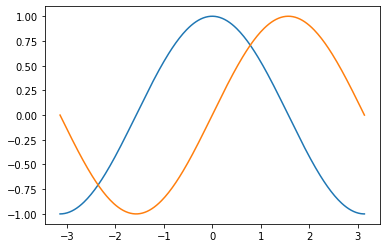

In [ ]:
from matplotlib import pyplot as plt
import numpy as np

X = np.linspace(-np.pi, np.pi, 256)
C, S = np.cos(X), np.sin(X)

plt.plot(X, C)
plt.plot(X, S)

plt.show()

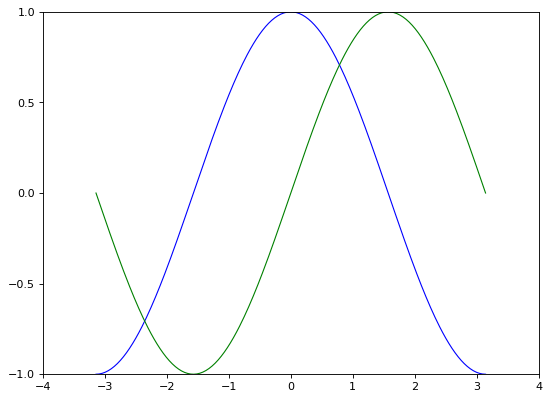

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Crea una figura nueva, de 8x6 pulgadas, con 80 puntos por pulgada
plt.figure(figsize=(8, 6), dpi=80)

# Crea un nuevo subplot, en una grilla de 1x1
plt.subplot(1, 1, 1)

X = np.linspace(-np.pi, np.pi, 256)
C, S = np.cos(X), np.sin(X)

# Plotea el coseno con una línea azul contínua de ancho 1 (en pixeles)
plt.plot(X, C, color="blue", linewidth=1.0, linestyle="-")

# Plotea el seno con una línea verde contínua de ancho 1 (en pixeles)
plt.plot(X, S, color="green", linewidth=1.0, linestyle="-")

# Rango del eje x
plt.xlim(-4.0, 4.0)

# Ponemos marcas (ticks) en el eje x
plt.xticks(np.linspace(-4, 4, 9))

# Rango del eje y
plt.ylim(-1.0, 1.0)

# Ponemos marcas (ticks) en el eje y
plt.yticks(np.linspace(-1, 1, 5))

# Podemos grabar el gráfico (con 72 dpi)
# plt.savefig("ejercicio_2.png)", dpi=72)

# Mostramos el resultado en pantalla
plt.show()

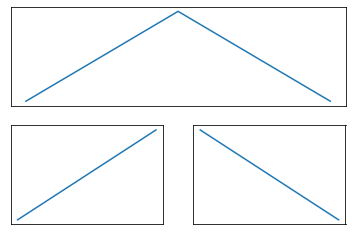

In [ ]:
import matplotlib.pyplot as plt

fig = plt.figure()
plt.subplot(2, 1, 1) # define la figura de arriba
plt.plot([0,1,2],[0,1,0]) # dibuja la curva
plt.xticks([]), plt.yticks([]) # saca las marcas

plt.subplot(2, 2, 3) # define la primera de abajo, que sería la tercera si fuera una grilla regular de 2x2
plt.plot([0,1],[0,1])
plt.xticks([]), plt.yticks([])

plt.subplot(2, 2, 4) # define la segunda de abajo, que sería la cuarta figura si fuera una grilla regular de 2x2
plt.plot([0,1],[1,0])
plt.xticks([]), plt.yticks([])

plt.show()

### 7.12
En este ejercicio te pedimos:

Modificá el código anterior para ponerles nombres a los ejes ("tiempo" y distancia al origen") y al gráfico.

Graficá 12 trayectorias en la misma figura, con diferentes colores.

Usá la estructura de subplots sugerida en el Ejercicio 7.11 para graficar tres pubplots en una figura:
>Arriba, grande, 12 trayectorias aleatorias como en el inciso anterior

>Abajo a la izquierda la trayectoria que más se aleja del origen.

>Abajo a la derecha la trayectoria que menos se aleja del origen.

Ojo, cuando decimos la que más o menos se aleja, nos referimos a en algún momento, no necesariamente a la que termina más cerca o más lejos.

Guardá tu solución del inciso 3 en el archivo random_walk.py. Debería verse aproximadamente como este plot:

406
entre
[233, 124]
124
entre
[162, 77]
77
466
entre
[246, 47]
47
entre
[403, 34]
34


<Figure size 432x288 with 0 Axes>

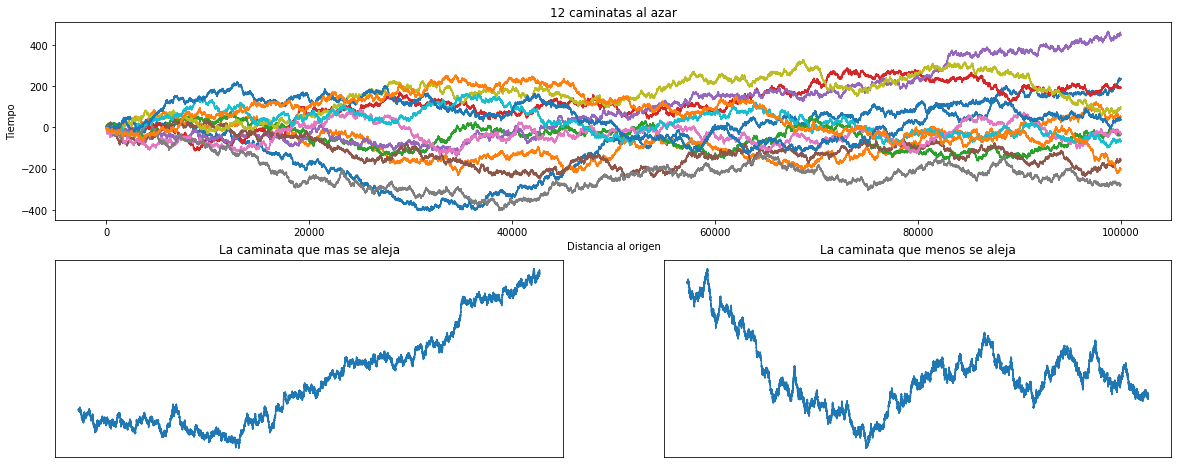

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def randomwalk(largo):
    pasos=np.random.randint (-1,2,largo)
    return pasos.cumsum()
fig = plt.figure()
fig= plt.figure(figsize=(20,8))
# fig(figsize=(8, 6), dpi=80)
plt.subplot(2, 1, 1) # define la figura de arriba
N = 100000
dist = 0
mayor = []
menor = []
distancia_menor = 400
for i in range (12):
    caminata = randomwalk(N)
    if abs(min(caminata)) > dist or abs(max(caminata)) > dist:
        mayores_val = [abs(min(caminata)),abs(max(caminata))]
        dist = max(mayores_val)
        print(dist)
        mayor = caminata

    elif abs(min(caminata)) < distancia_menor or abs(max(caminata)) < distancia_menor:
        print('entre')
        menores_val = [abs(min(caminata)),abs(max(caminata))]
        print(menores_val)
        distancia_menor = min(menores_val)
        print(distancia_menor)

        menor = caminata
    plt.plot(caminata)
plt.title('12 caminatas al azar')
plt.xlabel("Distancia al origen")
plt.ylabel("Tiempo")

plt.subplot(2, 2, 3) # define la primera de abajo, que sería la tercera si fuera una grilla regular de 2x2
plt.plot(mayor)
plt.title('La caminata que mas se aleja')
plt.xticks([]), plt.yticks([])

plt.subplot(2, 2, 4) # define la segunda de abajo, que sería la cuarta figura si fuera una grilla regular de 2x2
plt.plot(menor)
plt.title('La caminata que menos se aleja')

plt.xticks([]), plt.yticks([])

plt.show()
# N = 100000
# for i in range (12):
#     plt.plot(randomwalk(N))
# plt.title('12 caminatas al azar')
# plt.xlabel("Distancia al origen")
# plt.ylabel("Tiempo")
# plt.show()

# Unidad 6

### Ejercicio 6.1: Propagar por vecinos
El siguiente código propaga el fuego de cáda fósforo encendido a sus vecinos inmediatos (si son fósforos nuevos) a lo largo de toda la lista. Y repite esta operación mientras sea necesario. ¿Te animás a estimar cuántas operaciones puede tener que hacer, en el peor caso?


1. ¿Por qué los tests l[i+1]==0 y l[i-1]==0 de la función propagar_al_vecino no causan un IndexError en los bordes de la lista?
2. ¿Por qué propagar([0,0,0,0,1]) y propagar([1,0,0,0,0]), siendo entradas perfectamente simétricas, no generan la misma cantidad de repeticiones de llamadas a la función propagar_al_vecino?
3. Sobre la complejidad. Si te sale, calculá: * ¿Cuántas veces como máximo se puede repetir el ciclo while en una lista de largo n? * ¿Cuántas operaciones hace "propagar_al_vecino" en una lista de largo n? * Entonces, ¿cuántas operaciones hace como máximo esta versión de propagar en una lista de largo n? ¿Es un algoritmo de complejidad lineal o cuadrática?

In [ ]:
def propagar_al_vecino(l):
    modif = False
    n = len(l)
    for i,e in enumerate(l):
        if e==1 and i<n-1 and l[i+1]==0:
            l[i+1] = 1
            modif = True
        if e==1 and i>0 and l[i-1]==0:
            l[i-1] = 1
            modif = True
    return modif

def propagar(l):
    m = l.copy()
    veces=0
    while propagar_al_vecino(l):
        veces += 1

    print(f"Repetí {veces} veces la función propagar_al_vecino.")
    print(f"Con input {m}")
    print(f"Y obtuve  {l}")
    return m

propagar([0,0,0,0,1])
# propagar([0,0,1,0,0])
# propagar([1,0,0,0,0])

Repetí 4 veces la función propagar_al_vecino.
Con input [0, 0, 0, 0, 1]
Y obtuve  [1, 1, 1, 1, 1]
Repetí 2 veces la función propagar_al_vecino.
Con input [0, 0, 1, 0, 0]
Y obtuve  [1, 1, 1, 1, 1]
Repetí 1 veces la función propagar_al_vecino.
Con input [1, 0, 0, 0, 0]
Y obtuve  [1, 1, 1, 1, 1]


[1, 0, 0, 0, 0]

### Ejercicio 6.2: Propagar por como el auto fantástico¶
El siguiente código propaga el fuego inspirado en las luces del auto fantástico.

1. ¿Por qué se modificó la lista original?
2. ¿Por qué no quedó igual al estado propagado?
3. Corregí el código para que no cambie la lista de entrada.
4. ¿Cuántas operaciones hace como máximo propagar_a_derecha en una lista de largo n?
5. Sabiendo que invertir una lista ([::-1]) requiere una cantidad lineal de operaciones en la longitud de la lista ¿Cuántas operaciones hace como máximo propagar en una lista de largo n?

In [ ]:
def propagar_a_derecha(l):
    n = len(l)
    for i,e in enumerate(l):
        if e==1 and i<n-1:
            if l[i+1]==0:
                l[i+1] = 1
    return l
#%
def propagar_a_izquierda(l):
    return propagar_a_derecha(l[::-1])[::-1]
#%
def propagar(l):
    ld=propagar_a_derecha(l)
    lp=propagar_a_izquierda(ld)
    return lp
#%%
l = [0,0,0,-1,1,0,0,0,-1,0,1,0,0]
print("Estado original:  ",l)
print("Porpagando...")
lp=propagar(l)
print("Estado original:  ",l)
print("Estado propagado: ",lp)

Estado original:   [0, 0, 0, -1, 1, 0, 0, 0, -1, 0, 1, 0, 0]
Porpagando...
Estado original:   [0, 0, 0, -1, 1, 1, 1, 1, -1, 0, 1, 1, 1]
Estado propagado:  [0, 0, 0, -1, 1, 1, 1, 1, -1, 1, 1, 1, 1]


### Ejercicio 6.3: Propagar con cadenas
Esta versión usa métodos de cadenas para resolver el problema separando los fósforos en grupos sin fósforos quemados y analizando cada grupo. Sin embargo algo falla...

Preguntas:
1. ¿Porqué se acorta la lista?
2. ¿Podés corregir el error agregando un solo caracter al código?
3. ¿Te parece que este algoritmo es cuadrático como el Ejercicio 6.1 o lineal como el Ejercicio 6.2?

In [ ]:
def trad2s(l):
    '''traduce una lista con 1,0 y -1
    a una cadena con 'f', 'o' y 'x' '''
    d={1:'f', 0 :'o', -1:'x'}
    s=''.join([d[c] for c in l])
    return s

def trad2l(ps):
    '''traduce cadena con 'f', 'o' y 'x'
    a una lista con 1,0 y -1'''
    inv_d={'f':1, 'o':0, 'x':-1}
    l = [inv_d[c] for c in ps]
    return l

def propagar(l, debug = True):
    s = trad2s(l)
    if debug:
        print(s)#, end = ' -> ')
    W=s.split('x')
    print('X es -1', W)

    PW=[w if ('f' not in w) else 'f'*len(w) for w in W]
    print('PW', PW)

    ps=''.join(PW)
    if debug:
        print(ps)
    return trad2l(ps)

#%%
l = [0,0,0,-1,1,0,0,0,-1,0,1,0,0]
lp = propagar(l)
print("Estado original:  ",l)
print("Estado propagado: ",lp)
ver = trad2s(l)
ver

oooxfoooxofoo
X es -1 ['ooo', 'fooo', 'ofoo']
PW ['ooo', 'ffff', 'ffff']
oooffffffff
Estado original:   [0, 0, 0, -1, 1, 0, 0, 0, -1, 0, 1, 0, 0]
Estado propagado:  [0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1]


'oooxfoooxofoo'

### Ejercicio 6.6 al 6.9


In [ ]:

#%% 6.6
import csv

def parse_csv(nombre_archivo):
    '''
    Parsea un archivo CSV en una lista de registros
    '''
    with open(nombre_archivo) as f:
        rows = csv.reader(f)

        # Lee los encabezados
        headers = next(rows)
        registros = []
        for row in rows:
            if not row:    # Saltea filas sin datos
                continue
            registro = dict(zip(headers, row))
            registros.append(registro)

    return registros


def parse_csv(nombre_archivo, select = None, types=None, has_headers=True):
    '''
    Parsea un archivo CSV en una lista de registros.
    Se puede seleccionar sólo un subconjunto de las columnas, determinando el parámetro select, que debe ser una lista de nombres de las columnas a considerar.
    '''
    with open(nombre_archivo) as f:
        filas = csv.reader(f)


        # Lee los encabezados del archivo
        if has_headers:
            encabezados = next(filas)

        # Si se indicó un selector de columnas,
        #    buscar los índices de las columnas especificadas.
        # Y en ese caso achicar el conjunto de encabezados para diccionarios

        if select:
            indices = [encabezados.index(nombre_columna) for nombre_columna in select]
            encabezados = select
        else:
            indices = []

        registros = []
        for fila in filas:
            if not fila:    # Saltear filas vacías
                continue
            # Filtrar la fila si se especificaron columnas
            if indices:
                fila = [fila[index] for index in indices]

            if types:
                fila = [func(val) for func, val in zip(types, fila) ]
            # Armar el diccionario
            if has_headers:
                registro = dict(zip(encabezados, fila))
                registros.append(registro)
            if has_headers == False:
                registro = (fila[0],fila[1])
                registros.append(registro)
    return registros



### Ejercicio 6.13: Búsqueda lineal sobre listas ordenadas.
Modificá la función busqueda_lineal(lista, e) de la Sección 4.2 para el caso de listas ordenadas, de forma que la función pare cuando encuentre un elemento mayor a e. Llamá a tu nueva función busqueda_lineal_lordenada(lista,e) y guardala en el archivo busqueda_en_listas.py.

In [ ]:
def busqueda_lineal(lista, e):
    '''Si e está en la lista devuelve su posición, de lo
    contrario devuelve -1.
    '''
    pos = -1  # comenzamos suponiendo que e no está
    for i, z in enumerate(lista): # recorremos la lista
        if z == e:   # si encontramos a e
            pos = i  # guardamos su posición
            break    # y salimos del ciclo
    return pos

def busqueda_binaria(lista, x, verbose = False):
    '''Búsqueda binaria
    Precondición: la lista está ordenada
    Devuelve -1 si x no está en lista;
    Devuelve p tal que lista[p] == x, si x está en lista
    '''
    if verbose:
        print(f'[DEBUG] izq |der |medio')
    pos = -1 # Inicializo respuesta, el valor no fue encontrado
    izq = 0
    der = len(lista) - 1
    while izq <= der:
        medio = (izq + der) // 2
        if verbose:
            print(f'[DEBUG] {izq:3d} |{der:>3d} |{medio:3d}')
        if lista[medio] == x:
            pos = medio     # elemento encontrado!
        if lista[medio] > x:
            der = medio - 1 # descarto mitad derecha
        else:               # if lista[medio] < x:
            izq = medio + 1 # descarto mitad izquierda
    return pos

def donde_insertar(lista, x, verbose = False):
    '''Búsqueda binaria
    Precondición: la lista está ordenada
    Devuelve -1 si x no está en lista;
    Devuelve p tal que lista[p] == x, si x está en lista
    '''
    if verbose:
        print(f'[DEBUG] izq |len-1 |medio')
    pos = -1 # Inicializo respuesta, el valor no fue encontrado
    izq = 0
    der = len(lista) - 1

    while izq <= der:
        # print('izq',lista[izq])
        # print('der',lista[der])

        medio = (izq + der) // 2
        # print('medio',medio)
        # print('valor',lista[medio])

        if verbose:
            print(f'[DEBUG] {izq:3d} |{der:>3d} |{medio:3d}')

        if lista[medio] == x:
            pos = medio     # elemento encontrado!
        if lista[medio] > x:
            der = medio - 1 # descarto mitad derecha
            # print(der)
        else:               # if lista[medio] < x:
            izq = medio + 1 # descarto mitad izquierda
        if lista[medio] > x and lista[medio-1] < x :
            return medio

    # print('izq',lista[izq])
    # print('der',lista[der])
    # print('medio',lista[medio])
    return pos

# donde_insertar([1, 3, 5,6,8,9,10,11],3, verbose = True)
# donde_insertar([0,2,4,6,8], 7, verbose = True)
donde_insertar([0,2,4,6], 4)

2

In [ ]:
busqueda_binaria([1, 3, 5], 3, verbose = True)

[DEBUG] izq |der |medio
[DEBUG]   0 |  2 |  1
[DEBUG]   2 |  2 |  2


1

### 6.20 Gráficos de complejidad

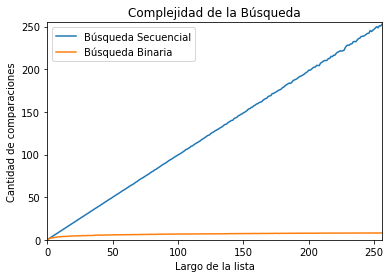

In [ ]:
import random
import matplotlib.pyplot as plt
import numpy as np

def busqueda_binaria(lista, x, verbose = False):
    '''Búsqueda binaria
    Precondición: la lista está ordenada
    Devuelve -1 si x no está en lista;
    Devuelve p tal que lista[p] == x, si x está en lista
    '''
    cont = 0
    if verbose:
        print(f'[DEBUG] izq |der |medio')
    pos = -1 # Inicializo respuesta, el valor no fue encontrado
    izq = 0
    der = len(lista) - 1
    while izq <= der:
        cont += 1
        medio = (izq + der) // 2
        if verbose:
            print(f'[DEBUG] {izq:3d} |{der:>3d} |{medio:3d}')
        if lista[medio] == x:
            pos = medio
        if lista[medio] > x:
            der = medio - 1
        else:
            izq = medio + 1
    return pos, cont

def busqueda_secuencial_(lista, x):
    '''Si x está en la lista devuelve el índice de su primera aparición,
    de lo contrario devuelve -1. Además devuelve la cantidad de comparaciones
    que hace la función.
    '''
    aux = 0
    pos = -1
    for i,z in enumerate(lista):
        aux += 1
        if z == x:
            pos = i
            break
    return pos, aux


def generar_lista(n, m):
    l = random.sample(range(m), k = n)
    l.sort()
    return l

def generar_elemento(m):
    return random.randint(0, m-1)

def experimento_secuencial_promedio(lista, m, k):
    comps_tot = 0
    for i in range(k):
        x = generar_elemento(m)
        comps_tot += busqueda_secuencial_(lista,x)[1]

    comps_prom = comps_tot / k
    return comps_prom

def experimento_binario_promedio(lista, m, k):
    comps_tot = 0
    for i in range(k):
        x = generar_elemento(m)
        comps_tot += busqueda_binaria(lista,x)[1]

    comps_prom = comps_tot / k
    return comps_prom

def graficar_bbin_vs_bseq(m, k):
    largos = np.arange(256) + 1 # estos son los largos de listas que voy a usar
    comps_promedio_secuencial = np.zeros(256) # aca guardo el promedio de comparaciones sobre una lista de largo i, para i entre 1 y 256.
    comps_promedio_bin = np.zeros(256)

    for i, n in enumerate(largos):
        lista_secuencial = generar_lista(n, m) # genero lista de largo n
        comps_promedio_secuencial[i] = experimento_secuencial_promedio(lista_secuencial, m, k)

    for i, n in enumerate(largos):
        lista_bin = generar_lista(n,m)
        comps_promedio_bin[i] = experimento_binario_promedio(lista_bin, m, k)


    # grafico
    plt.plot(largos,comps_promedio_secuencial,label = 'Búsqueda Secuencial')
    plt.plot(largos, comps_promedio_bin, label = 'Búsqueda Binaria')
    plt.xlabel("Largo de la lista")
    plt.ylabel("Cantidad de comparaciones")
    plt.title("Complejidad de la Búsqueda")
    plt.ylim(0,255)
    plt.xlim(0,256)
    plt.legend()
    plt.show()

m = 10000
k = 1000
graficar_bbin_vs_bseq(m,k)

# Unidad 5

### Respaso

In [ ]:
import random

dado = random.randint(1,6) # devuelve un entero aleatorio entre 1 y 6

# Generala
tirada=[]
for i in range(5):
    tirada.append(random.randint(1,6))

print(tirada)

[4, 2, 3, 4, 1]


### Ejercicio 5.1: Generala servida
Queremos estimar la probabilidad de obtener una generala servida (cinco dados iguales) en una tirada de dados. Podemos hacer la cuenta usando un poco de teoría de probabilidades, o podemos simular que tiramos los dados muchas veces y ver cuántas de esas veces obtuvimos cinco dados iguales. En este ejercicio vamos a usar el segundo camino.

Escribí una función tirar() que devuelva una lista con cinco dados generados aleatoriamente. Escribí otra función llamada es_generala(tirada) que devuelve True si y sólo si los cinco dados de la lista tirada son iguales.

Luego analizá el siguiente código. Correlo con N = 100000 varias veces y observá los valores que obtenés. Luego correlo algunas veces con N = 1000000 (ojo, hace un millón de experimentos, podría tardar un poco):


In [ ]:
def tirada_generala():
    """Devuelve lista con 5 numeros, representando un dado"""
    tirada=[]
    for i in range(5):
        tirada.append(random.randint(1,6))

    return tirada

def es_generala(tirada):
    """Devuelve True si obtuviste generala"""
    # print(all(x==tirada[0] for x in tirada)) # otra opcion
    if len(set(tirada)) == 1:
        return True
    else:
        return False

N = 1000
G = sum([es_generala(tirada_generala()) for i in range(N)])
prob = G/N
print(f'Tiré {N} veces, de las cuales {G} saqué generala servida.')
print(f'Podemos estimar la probabilidad de sacar generala servida mediante {prob:.6f}.')

Tiré 1000 veces, de las cuales 1 saqué generala servida.
Podemos estimar la probabilidad de sacar generala servida mediante 0.001000.


### Ejercicio 5.2: Generala no necesariamente servida
Ejercicio 5.2: Generala no necesariamente servida
Si uno juega con las reglas originales (se puede volver a tirar algunos de los cinco dados hasta dos veces, llegando hasta a tres tiradas en total) siguiendo una estrategia que intente obtener generala (siempre guardar los dados que más se repiten y tirar nuevamente los demás) es más probable obtener una generala que si sólo consideramos la generala servida.

Escribí una función llamada prob_generala(N) que, a partir de un parámetro N y usando las funciones del Ejercicio 5.1 realice una simulación con N repeticiones, para estimar la probabilidad de obtener una generala al finalizar una mano de tres tiradas. La función debe devolver un número entre 0 y 1. Guardala en un archivo generala.py para el cierre de la clase.

Extra: Hay gente que, si en la primera tirada le salen todos dados diferentes, los mete al cubilete y tira los cinco nuevamente. Otras personas, eligen uno de esos dados diferentes, lo guardan, y tiran sólo los cuatro restantes. ¿Podés determinar, por medio de simulaciones, si hay una de estas estrategias que sea mejor que la otra?

In [ ]:
def generala_tiradas(tiradas):
    """Genera una tirada y luego hace 2 tiradas mas de los dados no similares"""
    tirada = tirada_generala()
    for j in range(tiradas-1):
        # print(f"intento {j}",tirada)

        from collections import Counter
        tenencias = Counter()
        for s in tirada:
            tenencias[s] = tirada.count(s)

        # print(tenencias)
        # print(tenencias.most_common(1)[0][0])
        numero_ganador = tenencias.most_common(1)[0][0]
        for i in range(len(tirada)):
            if tirada[i] != numero_ganador:
                tirada[i] = random.randint(1,6)
    # print("intento 2",tirada)
    return tirada

# generala_tiradas(3)
# print(generala_tiradas(3))

def prob_generala(N):
    """Calcula la probabilidad"""
    # N = 1000
    G = sum([es_generala(generala_tiradas(3)) for i in range(N)])
    prob = G/N
    print(f'Tiré {N} veces, de las cuales {G} saqué generala')
    print(f'Podemos estimar la probabilidad de sacar generala servida mediante {prob:.6f}.')

prob_generala(1000)

Tiré 1000 veces, de las cuales 45 saqué generala
Podemos estimar la probabilidad de sacar generala servida mediante 0.045000.


Elecciones con reposición
A veces queremos elegir al azar un elemento de una lista y no solo un número. En el caso que vimos recién de los dados, nuestra lista sería [1, 2, 3, 4, 5, 6] pero podría ser también ['uno', 'dos', 'tres', 'cuatro', 'cinco', 'seis'].

La función random.choice() toma una secuencia y devuelve un elemento aleatorio.

> caras = ['uno', 'dos', 'tres', 'cuatro', 'cinco', 'seis']

> print(random.choice(caras))

Si queremos realizar múltiples elecciones aleatorias de la lista podemos usar la función random.choices()

> print(random.choices(caras,k=5))

Estos son experimentos con reposición en el sentido de que si en el primer dado sacamos un dos, al tirar el segundo dado podemos sacar otro dos, repitiendo el valor. El término reposición viene de pensar en una urna con bolitas. Si un dado lo pensamos como una urna con seis bolitas (etiquetadas del uno al seis), luego de sacar una bolita (tirar el dado una vez) reponemos la bolita que sacamos, de forma que en el siguiente experimento (tirar nuevamente el dado) podamos obtener el mismo valor.

### Ejercicio 5.3: Cocumpleaños
Haciendo miles de experimentos numéricos, estimá la probabilidad de que en un grupo de 30 personas elegidas al azar, dos cumplan años el mismo día. Escribí un programita que permita calcular esa probabilidad asumiendo que el año tiene 365 días.

Modificando un poco tu programa anterior, ¿podés calcular cuántas personas tiene que haber en un grupo para que sea más probable que dos cumplan años el mismo día que que todas cumplan en días diferentes?

Observación: Les dejamos una nota sobre las Simulaciones de Monte Carlo, por Adrián Paenza, que está relacionada con estos temas.

In [ ]:
import random
def cumples(n_personas):
    """Genera muestra de n_personas y devuelve si entre ellas hay coincidencia de cumples"""
    muestra=[0]*n_personas
    muestra2 = [random.randint(1,365) for s in range(n_personas)]
    # print(len(set(muestra2)))

    if len(set(muestra2)) < n_personas:
        # print(muestra2)
        return True
    else:
        return False


def prob_cumple(n_personas,N_total):
    """Calcula la probabilidad"""
    G = sum([cumples(n_personas) for i in range(N_total)])
    prob = G/N
    print(f'Tiré {N} veces, de las cuales {G} saqué generala')
    print(f'Podemos estimar la probabilidad de sacar generala servida mediante {prob:.6f}.')


prob_cumple(30,1000)

Tiré 1000 veces, de las cuales 714 saqué generala
Podemos estimar la probabilidad de sacar generala servida mediante 0.714000.


Naipes

In [ ]:
valores = [1, 2, 3, 4, 5, 6, 7, 10, 11, 12]
palos = ['oro', 'copa', 'espada', 'basto']
naipes = [(valor,palo) for valor in valores for palo in palos]

# 1 naipe
random.choice(naipes)
# con repo
random.choices(naipes, k=3)
#sin repo
random.sample(naipes,k=3)

[(7, 'copa'), (5, 'oro'), (2, 'oro')]

### Ejercicio 5.4: Envido
Teniendo en cuenta las reglas del Truco, estimá la probabilidad de obtener 31, 32 o 33 puntos de envido en una mano. ¿Son iguales estas tres probabilidades? ¿Por qué?

Observación: como corresponde, en esta materia jugamos al truco sin flor. Si no conocés las reglas del Truco y no te dan ganas de aprenderlo ahora, simplemente salteá este ejercicio.

Guardá este ejercicio en un archivo envido.py para entregar.

In [ ]:
def calcular_envido():
    mano = random.sample(naipes,k=3)
    carta1 = mano[0]
    carta2 = mano[1]
    carta3 = mano[2]
    envido = [0,0,0]

    if carta1[1] == carta2[1]:
        una = carta1[0]
        dos = carta2[0]
        if carta1[0]>= 10:
            una = 0
        if carta2[0]>= 10:
            dos = 0
        envido[0] = 20 + una + dos

    if carta2[1] == carta3[1]:
        una = carta2[0]
        dos = carta3[0]
        if carta2[0]>= 10:
            una = 0
        if carta3[0]>= 10:
            dos = 0
        envido[1] = 20 + una + dos

    if carta1[1] == carta3[1]:
        una = carta1[0]
        dos = carta3[0]
        if carta1[0]>= 10:
            una = 0
        if carta3[0]>= 10:
            dos = 0
        envido[2] = 20 + una + dos
    return max(envido)

calcular_envido()
def prob_envido(N):
    uno = 0
    dos = 0
    tres = 0
    for i in range(N):
        env = calcular_envido()
        if env == 31:
            uno += 1
        elif env == 32:
            dos += 1
        elif env == 33:
            tres += 1

    prob1 = uno/N
    prob2 = dos/N
    prob3 = tres/N
    print(f'Podemos estimar la probabilidad de 31 {prob1:.6f} de 32 {prob2:.6f} de 33 {prob3:.6f}.')

prob_envido(1000)

Podemos estimar la probabilidad de 31 0.028000 de 32 0.015000 de 33 0.013000.


### Mezclar
La última función que queremos introducir es útil en muchos contextos. En los juegos de naipes, para continuar con nuestro ejemplo, es muy usual mezclar el mazo entero antes de repartir. En Python usamos la función shuffle del módulo random.



In [ ]:
import random
valores = [1, 2, 3, 4, 5, 6, 7, 10, 11, 12]
palos = ['oro', 'copa', 'espada', 'basto']
naipes = [(valor,palo) for valor in valores for palo in palos]
print(naipes)
random.shuffle(naipes)
print(naipes)

"""Observá que la función shuffle() modificó la lista que le pasamos como parámetro.
Una vez mezclado el mazo, podemos consultar las tres cartas que quedaron al final:"""

naipes[-3:]

# o directamente sacarlas del mazo:

n1 = naipes.pop()
n2 = naipes.pop()
n3 = naipes.pop()
print(f'Repartí el {n1[0]} de {n1[1]}, el {n2[0]} de {n2[1]} y el {n3[0]} de {n3[1]}. Quedan {len(naipes)} naipes en el mazo.')

[(1, 'oro'), (1, 'copa'), (1, 'espada'), (1, 'basto'), (2, 'oro'), (2, 'copa'), (2, 'espada'), (2, 'basto'), (3, 'oro'), (3, 'copa'), (3, 'espada'), (3, 'basto'), (4, 'oro'), (4, 'copa'), (4, 'espada'), (4, 'basto'), (5, 'oro'), (5, 'copa'), (5, 'espada'), (5, 'basto'), (6, 'oro'), (6, 'copa'), (6, 'espada'), (6, 'basto'), (7, 'oro'), (7, 'copa'), (7, 'espada'), (7, 'basto'), (10, 'oro'), (10, 'copa'), (10, 'espada'), (10, 'basto'), (11, 'oro'), (11, 'copa'), (11, 'espada'), (11, 'basto'), (12, 'oro'), (12, 'copa'), (12, 'espada'), (12, 'basto')]
[(3, 'oro'), (5, 'copa'), (3, 'espada'), (7, 'basto'), (11, 'espada'), (6, 'copa'), (3, 'copa'), (11, 'basto'), (12, 'oro'), (12, 'espada'), (1, 'oro'), (4, 'espada'), (5, 'oro'), (1, 'espada'), (12, 'copa'), (11, 'oro'), (4, 'copa'), (6, 'oro'), (7, 'copa'), (11, 'copa'), (7, 'espada'), (6, 'basto'), (5, 'espada'), (4, 'basto'), (2, 'copa'), (10, 'basto'), (2, 'espada'), (6, 'espada'), (10, 'oro'), (5, 'basto'), (3, 'basto'), (10, 'espada'), 

### Ejercicio 5.5: Calcular pi
Es interesante ver cómo los algoritmos estocásticos (basados en elecciones aleatorias) también sirven para resolver problemas que no tienen nada de estocásticos. En este ejercicio vas a usar el generador random() para aproximar pi.

Por definición pi es el área del círculo de radio uno. Si generamos puntos (x,y) con:


In [ ]:
def generar_punto():
    x = random.random()
    y = random.random()
    return x,y
"""tendremos puntos dentro del cuadrado [0, 1]x[0, 1]. Algunos de estos puntos del cuadrado caerán dentro del círculo unitario
(los que cumplan que x^2 + y^2 < 1) y otros puntos caerán afuera. La proporción de puntos que caigan dentro del cuarto de círculo
guardará relación con la proporción entre el área del cuarto de círculo y el área del cuadrado. Obviamente hay una componente aleatoria,
pero a medida que la cantidad de puntos crece, la proporción de puntos se acercará a la proporción entre las dos áreas."""

generar_punto()

(0.6614898550392819, 0.2994176683860972)

### Ejercicio 5.6: Gaussiana
Con random.random() generamos valores aleatorios entre 0 y 1 con una distribución uniforme. En esa distribución, todos los valores posibles tienen la misma probabilidad de ser seleccionados. También es posible generar valores aleatorios con otras distribuciones. Una de las distribuciones más importantes es la distribución normal o Gaussiana.

La distribución normal tiene dos parámetros, denominados media y desvío estándar y denotados usualmente con las letras griegas mu y sigma, respectivamente.



In [ ]:
# for i in range(6):
#     print(f'{random.normalvariate(0,1):.2f}', end=', ')

temp = []
for i in range(99):
    temperatura = random.normalvariate(37.5,0.2)
    temp.append(temperatura)
    # print(f'{temperatura:.2f}', end=', ')

print('Maximo', f'{max(temp):.2f}')
print('Minimo',f'{min(temp):.2f}')
print('Promedio',f'{sum(temp)/99:.2f}')
temp.sort()
print('Mediana',f'{temp[50]:.2f}')

# Para encontrar el máximo y mínimo podés usar y agrandar tu código de busqueda_en_listas.py o usar las primitivas max() y min() de Python. El promedio es la suma de los valores dividido su cantidad; podés programarla desde cero o usar la primitiva sum() y un cociente por n. Finalmente, la mediana de una cantidad impar de valores es el valor en la posición central cuando los datos están ordenados. Acá podés usar el método sort() de listas

### 5.2 NumPy

In [ ]:
import numpy as np
a = np.array([1, 2, 3, 4, 5, 6])
a = np.array([[1, 2, 3, 4], [5, 6, 7, 8], [9, 10, 11, 12]])

### Ejercicio 5.7: arange() y linspace()
Generá un vector que tenga los números impares entre el 1 y el 19 inclusive usando arange(). Repetí el ejercicio usando linspace(). ¿Qué diferencia hay en el resultado?

Especificar el tipo de datos

Si no lo especificás, el tipo de datos (por omisión) de los arreglos es el punto flotante (np.float64). Sin embargo, podés explicitar otro tipo de datos usando la palabra clave dtype.

>>> x = np.ones(2, dtype=np.int64)
>>> x
array([1, 1])
En estos dos casos el 64 de los tipos de datos se refiere a la cantidad de bits usados para representar el número en el sistema binario: 64 bits.

In [ ]:
import numpy as np
np.arange(0,20)
np.linspace(0, 20)
x = np.ones(2, dtype=np.int64)
x

array([1, 1])

In [ ]:
a = np.array([1, 2, 3, 4, 5, 6])
# np.save('filename', a)
b = np.load('filename.npy')
b

FileNotFoundError: ignored

### Ejercicio 5.8: Guardar temperaturas
Ampliá el código de termometro.py que escribiste en el Ejercicio 5.6 para que guarde el vector con las temperaturas simuladas en el directorio Data de tu carpeta de ejercicios, en un archivo llamado Temperaturas.npy. Hacé que corra 999 veces en lugar de solo 99.

In [ ]:
import random
import numpy as np
def temperaturas(n):
    temp = []
    for i in range(n):
        temperatura = random.normalvariate(37.5,0.2)
        temp.append(temperatura)

    print('Maximo', f'{max(temp):.2f}')
    print('Minimo',f'{min(temp):.2f}')
    print('Promedio',f'{sum(temp)/99:.2f}')
    temp.sort()
    print('Mediana',f'{temp[50]:.2f}')

    # np.save('../Data/temperaturas', temp)
    np.save('Temperaturas.npy', temp)


def ejecutar(mensaje):
    print(mensaje)

if __name__ == "__main__":
    nombre_archivo = "../Data/camion.csv"
    temperaturas(999)
    ejecutar("Se ejecuto tu programa")
    # print(funcion_a_corer)




Maximo 38.25
Minimo 36.81
Promedio 378.42
Mediana 37.16
Se ejecuto tu programa


### Ejercicio 5.9: Empezando a plotear¶
En un rato vamos a empezar a hacer gráficos con Python. Aquí solo un botón de muestra.

Escribí un archivo plotear_temperaturas.py que lea el archivo de datos Temperaturas.npy con 999 mediciones simuladas que creaste recién y, usando el siguiente ejemplo, hacé un histograma de las temperaturas simuladas:

import matplotlib.pyplot as plt
plt.hist(temperaturas,bins=25)
plt.show() #el show no hace falta en algunos entornos. A veces lo omitiremos.
Ajustá la cantidad de bins para que el gráfico se vea lo mejor posible.

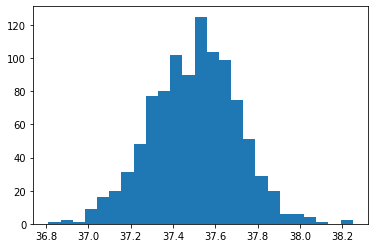

In [ ]:
import matplotlib.pyplot as plt
temperaturas = np.load('Temperaturas.npy')
plt.hist(temperaturas,bins=25)
plt.show()

### Ejercicio 5.10: Crear
Implementá la función crear_album(figus_total) que devuelve un álbum (vector) vacío con figus_total espacios para pegar figuritas.

### Ejercicio 5.11: Incompleto¶
¿Cuál sería el comando de Python que nos dice si hay al menos un cero en el vector que representa el álbum? ¿Qué significa que haya al menos un cero en nuestro vector?

Implementá la función album_incompleto(A) que recibe un vector y devuelve True si el álbum A no está completo y False si está completo.

### Ejercicio 5.12: Comprar
Alguna de las funciones que introdujimos en la Sección 5.1 sirve para devolver un número entero aleatorio dentro de un rango (¿cuál era?). Implementá una función comprar_figu(figus_total) que reciba el número total de figuritas que tiene el álbum (dado por el parámetro figus_total) y devuelva un número entero aleatorio que representa la figurita que nos tocó.

In [ ]:
import random
import numpy as np
def crear_album(figus_total):
    return [0]*figus_total

crear_album(10)

def album_incompleto(A):
    if 0 in A:
        return True
    else:
        return False

figus_total = 10
A = crear_album(figus_total)
album_incompleto(A)


def comprar_figu(figus_total):
    return random.randint(0,figus_total)
comprar_figu(figus_total)

10

### Ejercicio 5.13: Cantidad de compras
Implementá la función cuantas_figus(figus_total) que, dado el tamaño del álbum (figus_total), genere un álbum nuevo, simule su llenado y devuelva la cantidad de figuritas que se debieron comprar para completarlo.

In [ ]:
def cuantas_figus(figus_total):
    album = crear_album(figus_total)
    figus = 0
    while album_incompleto(album):
      figu = comprar_figu(figus_total-1)
      # print(figu)
      album[figu] = 1
      # print(album)
      figus += 1
      # print(album)
    return figus
cantidad_figus = cuantas_figus(10)
print(cantidad_figus)

### Ejercicio 5.14:
Ejecutá n_repeticiones = 1000 veces la función anterior utilizando figus_total = 6 y guardá en una lista los resultados obtenidos en cada repetición. Con los resultados obtenidos estimá cuántas figuritas hay que comprar, en promedio, para completar el álbum de seis figuritas.

Ayuda: El comando np.mean(l) devuelve el promedio de la lista l.

¿Podés crear esta lista usando una comprensión de listas?

In [ ]:
# [<expresion> for <variable> in <secuencia> if <condicion]

  myn = [cuantas_figus(6) for s in range(100)]
  print(np.mean(myn))

13.45


### Ejercicio 5.15:
Calculá n_repeticiones=100 veces la función cuantas_figus(figus_total=670) y guardá los resultados obtenidos en cada repetición en una lista. Con los resultados obtenidos estimá cuántas figuritas hay que comprar, en promedio, para completar el álbum (de 670 figuritas).

Guardá todo lo que hiciste hasta aquí sobre figuritas en un archivo figuritas.py. Lo que sigue profundiza un poco más en el asunto.

In [ ]:
myn = [cuantas_figus(670) for s in range(100)]
print(np.mean(myn))
np.save('Figuritas.npy', myn)

4686.06


### Ejercicio 5.16:
Simulá la generación de un paquete con cinco figuritas, sabiendo que el álbum es de 670. Tené en cuenta que, como en la vida real, puede haber figuritas repetidas en un paquete.
### Ejercicio 5.17:
Implementá una función comprar_paquete(figus_total, figus_paquete) que, dado el tamaño del álbum (figus_total) y la cantidad de figuritas por paquete (figus_paquete), genere un paquete (lista) de figuritas al azar.

In [ ]:
def comprar_paquete(figus_total,total_paquete):
    return [comprar_figu(figus_total-1) for s in range(total_paquete)]

comprar_paquete(670,5)

[591, 218, 2, 250, 129]

### Ejercicio 5.18:
Implementá una función cuantos_paquetes(figus_total, figus_paquete) que dado el tamaño del álbum y la cantidad de figus por paquete, genere un álbum nuevo, simule su llenado y devuelva cuántos paquetes se debieron comprar para completarlo.

In [ ]:
def cuantos_paquetes(figus_total,figus_paquete=5):
    album = crear_album(figus_total)
    paquetes = 0
    while album_incompleto(album):
        paq = comprar_paquete(figus_total,figus_paquete)
        # print(figu)
        for i in paq:
            album[i] = 1
        paquetes += 1
        #print(album)
        #print(paquetes)
    return int(paquetes)

paq_tot = cuantos_paquetes(10)
print(paq_tot)

4


### Ejercicio 5.19:
Calculá n_repeticiones = 100 veces la función cuantos_paquetes, utilizando figus_total = 670, figus_paquete = 5. Guarda los resultados obtenidos en una lista y calculá su promedio. Si te da la compu, hacelo con 1000 repeticiones.

In [ ]:
#myn = [cuantos_paquetes(670 , figus_paq) for s in range(1000)]
myn = [cuantos_paquetes(670 , figus_paq) for s in range(100)]

#print(myn)
print(np.mean(myn))
np.save('Figuritas.npy', myn)

942.881


In [ ]:
import matplotlib.pyplot as plt

def calcular_historia_figus_pegadas(figus_total, figus_paquete):
    album = crear_album(figus_total)
    historia_figus_pegadas = [0]
    while album_incompleto(album):
        paquete = comprar_paquete(figus_total, figus_paquete)
        while paquete:
            album[paquete.pop()] = 1
        figus_pegadas = (album>0).sum()
        historia_figus_pegadas.append(figus_pegadas)
    return historia_figus_pegadas

figus_total = 670
figus_paquete = 5

plt.plot(calcular_historia_figus_pegadas(figus_total, figus_paquete))
plt.xlabel("Cantidad de paquetes comprados.")
plt.ylabel("Cantidad de figuritas pegadas.")
plt.title("La curva de llenado se desacelera al final")
plt.show()

AttributeError: ignored

### Ejercicio 5.20:
Utilizando lo implementado en el ítem anterior, estimá la probabilidad de completar el álbum con 850 paquetes o menos.

Sugerencia: No leas esto antes de hacer el ejercicio. Hacelo primero y luego miralo. En este ejercicio resulta más compacto usar n_paquetes_hasta_llenar=np.array(lista) para convertir a vector la lista conteniendo cuántos paquetes compraste en cada experimento hasta llenar el álbum. Trabajar con vectores tiene ventajas. Por ejemplo probá la siguiente instrucción:

(n_paquetes_hasta_llenar <= 850).sum()

In [ ]:
lista = [cuantos_paquetes(670 , figus_paq) for s in range(1000)]

n_paquetes_hasta_llenar=np.array(lista)
#print(n_paquetes_hasta_llenar)
#print((n_paquetes_hasta_llenar <= 850).sum())
print(f"La probabilidad de llenar el album con 850 paquetes es de {(n_paquetes_hasta_llenar <= 850).sum()}%")

La probabilidad de llenar el album con 850 paquetes es de 311%


### Ejercicio 5.21 Plotear el histograma
Usá un código similar al del Ejercicio 5.9 para hacer un histograma de la cantidad de paquetes que se compraron en cada experimento, ajustando la cantidad de bins para que el gráfico se vea lo mejor posible.

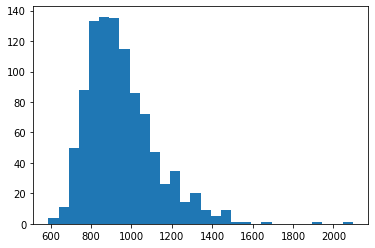

In [ ]:
import matplotlib.pyplot as plt

plt.hist(lista,bins=30)
plt.show()

### Ejercicio 5.22:
Utilizando lo implementado, estimá cuántos paquetes habría que comprar para tener una chance del 90% de completar el álbum

In [ ]:
# resultados = [res for res in [lista for _ in range(100)] if res >= 90]

lista = [cuantos_paquetes(670 , figus_paq) for s in range(100)]

total_paq= np.array(lista)
print(total_paq)
print((total_paq <= 850).sum())
print(f"La probabilidad de llenar el album con 850 paquetes es de {(n_paquetes_hasta_llenar <= 850).sum()}%")


[ 800 1223  872 1026  874  956 1021  812  890  715 1074  778  865  756
  671 1196 1232  990  777  819  751  825 1110  692 1097 1077  955  862
  877  785  874 1040  790  896  773 1072  807  797  753 1102  817  810
 1621  774  758 1315  720  868 1245  775  907 1150 1005  877 1056  771
 1350 1208  842  791 1036  891  953  922 1007  976 1025  812  998 1107
  875  881 1004  830 1148  952  935  861 1473 1039 1073  734 1026  750
  978  891  866  968  899 1162  914  872 1067  896  819  832  873  974
  871 1060]
32
La probabilidad de llenar el album con 850 paquetes es de 38%


In [ ]:
# proba = (n_paquetes_hasta_llenar <= paquetes).sum()
proba = 0
paquetes = 0
while proba <= 90:
    proba = (n_paquetes_hasta_llenar <= paquetes).sum()
    paquetes += 1
print(paquetes)

1141


### Ejercicio 5.25: Histograma de altos de Jacarandás
Usando tu trabajo en el Ejercicio 4.16, generá un histograma con las alturas de los Jacarandás en el dataset.

Tu código debería verse similar a este:


Observación: Spyder tiene opciones para mostrar las figuras dentro de la misma ventana o en una ventana nueva (Tools -> Preferences -> IPython console -> Graphics -> Backend). Te recomendamos generarlas en una ventana nueva. Luego, con plt.clf() podés borrar la figura actual y con plt.figure() generás una nueva figura por si querés dejar varias abiertas a la vez.

(array([187., 423., 189., 488., 166., 311., 317., 161., 363., 166., 164.,
        146.,  42.,  57.,  11.,  55.,   6.,   0.,   1.,   0.,   1.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   1.]),
 array([ 1. ,  2.6,  4.2,  5.8,  7.4,  9. , 10.6, 12.2, 13.8, 15.4, 17. ,
        18.6, 20.2, 21.8, 23.4, 25. , 26.6, 28.2, 29.8, 31.4, 33. , 34.6,
        36.2, 37.8, 39.4, 41. , 42.6, 44.2, 45.8, 47.4, 49. ]),
 <a list of 30 Patch objects>)

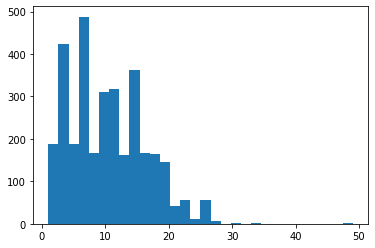

In [ ]:
import matplotlib.pyplot as plt
arboleda = leer_parque('arbolado.csv')
A =[float(arbol['altura_tot']) for arbol in arboleda if arbol['nombre_com'] == 'Jacarandá']

# import os
# import matplotlib.pyplot as plt
# os.path.join('..', 'Data', 'arbolado-en-espacios-verdes.csv')
# arboleda = leer_arboles(nombre_archivo)
# print(A)
# altos = [comprensión de listas]
plt.hist(A,bins=30)

### Ejercicio 5.26: Scatterplot (diámetro vs alto) de Jacarandás
En este ejercicio introducimos un nuevo tipo de gráfico: el gráfico de dispersión o scatterplot. El mismo usa coordenadas cartesianas para mostrar los valores de dos variables para un conjunto de datos.

En este caso vamos a graficar un punto en el plano (x,y) por cada árbol en el dataset (o para cada arbol de cierta especie). El punto correspondiente a un árbol con diámetro d y altura h será ubicado en la posición x=d y y=h. Este tipo de gráfico permite visualizar relaciones o tendencias entre las variables y es muy útil en el análisis exploratorio de datos.

Usando como base tu trabajo del Ejercicio 4.17, vas a generar un scatterplot para visualizar la relación entre diámetro y alto de los Jacarandás del dataset.

Si ya tenés una lista o un vector d con diámetros y otra h con altos, es sencillo hacer un primer scatterplot:

Algunas recomendaciones:

1. Convertí la lista generada en un ndarray de numpy, de esa forma podés usar rebanadas para obtener un vector d con diámteros y otro h con alturas inmediatamente.

2. Mirá algún ejemplo como este y tratá de entender cómo se usan los parámetros opcionales s (de size, tamaño) y c (de color) y alpha (de transparencia) de la función matplotlib.pyplot.scatter.

3. Usando el parámetro alpha hacé que el gráfico permita visualizar dónde hay mayor densidad de datos.

¿Ves alguna relación entre el diámetro y el alto de los Jacarndás? ¿Te parece que es una relación lineal o de otro tipo?

Agregale nombres a los ejes y a la figura usando los siguientes comandos:

plt.xlabel("diametro (cm)")
plt.ylabel("alto (m)")
plt.title("Relación diámetro-alto para Jacarandás")

Text(0.5, 1.0, 'Relación diámetro-alto para Jacarandás')

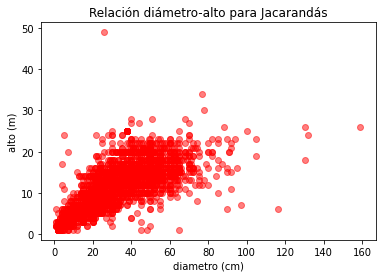

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
arboleda = leer_parque('arbolado.csv')
h =[float(arbol['altura_tot']) for arbol in arboleda if arbol['nombre_com'] == 'Jacarandá']
h1= np.array(h)
d =[float(arbol['diametro']) for arbol in arboleda if arbol['nombre_com'] == 'Jacarandá']
d1= np.array(d)

plt.scatter(d1,h1, c = 'r', alpha = 0.5)
plt.xlabel("diametro (cm)")
plt.ylabel("alto (m)")
plt.title("Relación diámetro-alto para Jacarandás")

###Ejercicio 5.27: Scatterplot para diferentes especies
Ahora vamos a usar la función medidas_de_especies() definida en el Ejercicio 4.18.

Comenzando con éste código, hacé tres gráficos como en el ejercicio anterior, uno por cada especie.


¿Se mantienen las relaciones que viste en el ejercicio anterior para las tres especies? ¿Hay diferencias entre las especies? Para un mismo alto, ¿cuál tiene mayor diámetro (tipicamente)?

Para poder comparar diferentes especies resulta conveniente fijar los límites en los ejes x e y en las diferentes figuras usando las funciones xlim() e ylim(). A continuación un ejemplo:

plt.xlim(0,30)
plt.ylim(0,100)
Acordate siempre de ponerle título a las figuras y nombres y unidades a los ejes. Guardá los últimos tres ejercicios dentro de tres funciones diferentes en tu archivo arboles.py. Te pediremos que lo entregues en la próxima página.

Extra: ¿podés hacer un solo gráfico que muestre dos de estas tres especies en diferentes colores y resulte claro? ¿Y las tres especies?

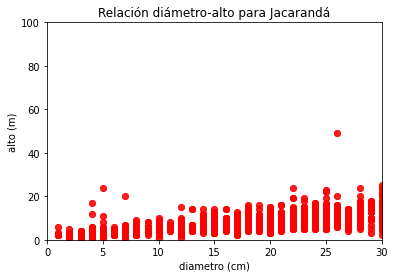

In [ ]:
import os
import matplotlib.pyplot as plt

# os.path.join('..', 'Data', 'arbolado.csv')
arboleda = leer_parque('arbolado.csv')
especies = ['Eucalipto', 'Palo borracho rosado', 'Jacarandá']
medidas = medidas_de_especies(especies, arboleda)

# print(medidas['Eucalipto'])
def grafico_medidas(medidas, especie):
    heu =[float(arbol['altura_tot']) for arbol in medidas[especie]]
    he1= np.array(h)
    deu =[float(arbol['diametro']) for arbol in medidas[especie]]
    deu1= np.array(d)
    plt.scatter(d1,h1, c = 'r', alpha = 0.5)
    plt.xlim(0,30)
    plt.ylim(0,100)
    plt.xlabel("diametro (cm)")
    plt.ylabel("alto (m)")
    plt.title(f"Relación diámetro-alto para {especie}")

grafico_medidas(medidas,'Eucalipto')
grafico_medidas(medidas,'Palo borracho rosado')
grafico_medidas(medidas,'Jacarandá')


# Unidad 4


In [ ]:
def funcion_a_correr():
    pass

def ejecutar(mensaje):
    print(mensaje)

if __name__ == "__main__":
    nombre_archivo = "../Data/camion.csv"
    ejecutar("Se ejecuto tu programa")
    print(funcion_a_corer)

## Ejercicio 4.1


In [ ]:
# Aseveraciones (assert)
# El comando assert se usa para un control interno del programa.
# Si la expresión que queremos verificar es False, se levanta una excepción de tipo AssertionError. La sintaxis de assert es la siguiente.

# assert <expresion> [, 'Mensaje']
#Por ejemplo

# assert isinstance(10, int), 'Necesito un entero (int)'

def add(x, y):
    assert isinstance(x, int), 'Necesito un entero (int)'
    assert isinstance(y, int), 'Necesito un entero (int)'
    return x + y

add(1,2)


# 4.1 falla en el pop
# 4.2 no entiendo que pide ya nos habian pedido debugear

3

## 4.3.0

Problema: Dada una lista lista y un elemento e devolver el índice de e en lista si e está en lista, y devolver -1 si e no está en lista

Vemos que usar la función index() resuelve nuestro problema si el valor buscado está en la lista, pero si el valor no está no sólo no devuelve un -1, sino que se produce un error.

El problema es que para poder aplicar la función index() debemos estar seguros de que el valor está en la lista, y para averiguar eso Python nos provee del operador in:


***El algoritmo de búsqueda lineal tiene un comportamiento proporcional a la longitud de la lista involucrada, o que es un algoritmo lineal.***

In [ ]:
print([1, 3, 5, 7].index(5))
print(5 in [1, 3, 5, 7])


def busqueda_con_index(lista, e):
    '''Busca un elemento e en la lista.

    Si e está en lista devuelve el índice,
    de lo contrario devuelve -1.
    '''
    if e in lista:
        pos = lista.index(e)
    else:
        pos = -1
    return pos
busqueda_con_index([1, 4, 54, 3, 0, -1], -1)

def busqueda_lineal_primitiva(lista, e):
    '''Si e está en la lista devuelve su posición, de lo
    contrario devuelve -1.
    '''
    pos = -1  # comenzamos suponiendo que e no está
    i = 0
    for z in lista:  # recorremos los elementos de la lista
        if z == e:   # si encontramos a e
            pos = i  # guardamos su posición
            break    # y salimos del ciclo
        i += 1
    return pos

def busqueda_lineal_enumerate(lista, e):
    '''Si e está en la lista devuelve su posición, de lo
    contrario devuelve -1.
    '''
    pos = -1  # comenzamos suponiendo que e no está
    for i, z in enumerate(lista): # recorremos la lista
        if z == e:   # si encontramos a e
            pos = i  # guardamos su posición
            break    # y salimos del ciclo
    return pos



2
True


## 4.3: Búsquedas de un elemento

In [ ]:
def buscar_u_elemento(lista, elemento):
    '''Si e está en la lista devuelve su posición, de lo contrario devuelve -1.
    '''
    pos = -1  # comenzamos suponiendo que e no está
    i = 0
    for z in lista:  # recorremos los elementos de la lista
        if z == elemento:   # si encontramos a e
            pos = i  # guardamos su posición
        i += 1
    return pos

def buscar_n_elemento(lista, elemento):
    '''Si e está en la lista devuelve su posición, de lo contrario devuelve -1.
    '''
    pos = -1  # comenzamos suponiendo que e no está
    i = 0
    cantidad = 0
    for z in lista:  # recorremos los elementos de la lista
        if z == elemento:   # si encontramos a e
            pos = i  # guardamos su posición
            cantidad += 1
        i += 1
    return pos, cantidad

print(buscar_n_elemento([1,2,3,2,3,4],1))

print(buscar_n_elemento([1,2,3,2,3,4],2))

print(buscar_n_elemento([1,2,3,2,3,4],3))

print(buscar_n_elemento([1,2,3,2,3,4],5))


(0, 1)
(3, 2)
(4, 2)
(-1, 0)


### Ejercicio 4.4: Búsqueda de máximo y mínimo
Agregale a tu archivo busqueda_en_listas.py una función maximo() que busque el valor máximo de una lista de números positivos. Python tiene el comando max que ya hace esto, pero como práctica te proponemos que completes el siguiente código:


In [ ]:
def maximo(lista):
    '''Devuelve el máximo de una lista, la lista debe ser no vacía.
    '''
    # m guarda el máximo de los elementos a medida que recorro la lista.
    m = lista[0] # Lo inicializo en 0
    for e in lista: # Recorro la lista y voy guardando el mayor
        if e > m:
            m = e
    return m
print(maximo([1,2,7,2,3,4]))

print(maximo([1,2,3,4]))

print(maximo([-5,4]))

print(maximo([0,-2,-3]))


def minimo(lista):
    '''Devuelve el minimo de una lista, la lista debe ser no vacía.
    '''
    # m guarda el máximo de los elementos a medida que recorro la lista.
    m = lista[0] # Lo inicializo en 0
    for e in lista: # Recorro la lista y voy guardando el mayor
        if e < m:
            m = e
    return m

print(minimo([1,2,7,2,3,4]))

print(minimo([1,2,3,4]))

print(minimo([-5,4]))

print(minimo([0,-2,-3]))




7
4
4
0
1
1
-5
-3


### Ejercicio 4.5: Invertir una lista
Escribí una función invertir_lista(lista) que dada una lista devuelva otra que tenga los mismos elementos pero en el orden inverso. Es decir, el que era el primer elemento de la lista de entrada deberá ser el último de la lista de salida y análogamente con los demás elementos.



In [ ]:
def invertir_lista(lista):
    invertida = [0]*len(lista)
    print(lista)
    long = len(lista) -1
    for e in lista: # Recorro la lista
        invertida[long] = e
        print(long, invertida)
        long-= 1
    return invertida
# invertir_lista([1, 2, 3, 4, 5])
# invertir_lista( ['Bogotá', 'Rosario', 'Santiago', 'San Fernando', 'San Miguel'])


['Bogotá', 'Rosario', 'Santiago', 'San Fernando', 'San Miguel']
4 [0, 0, 0, 0, 'Bogotá']
3 [0, 0, 0, 'Rosario', 'Bogotá']
2 [0, 0, 'Santiago', 'Rosario', 'Bogotá']
1 [0, 'San Fernando', 'Santiago', 'Rosario', 'Bogotá']
0 ['San Miguel', 'San Fernando', 'Santiago', 'Rosario', 'Bogotá']


['San Miguel', 'San Fernando', 'Santiago', 'Rosario', 'Bogotá']

### Ejercicio 4.6: Propagación
Imaginate una fila con varios fósforos uno al lado del otro. Los fósforos pueden estar en tres estados: nuevos, prendidos fuego o ya gastados (carbonizados). Representaremos esta situación con una lista L con un elemento por fósforo, que en cada posición tiene un 0 (nuevo), un 1 (encendido) o un -1 (carbonizado). El fuego se propaga inmediatamente de un fósforo encendido a cualquier fósforo nuevo que tenga a su lado. Los fósforos carbonizados no se encienden nuevamente.

Escribí una función llamada propagar que reciba un vector con 0's, 1's y -1's y devuelva un vector en el que los 1's se propagaron a sus vecinos con 0. Guardalo en un archivo propaga.py.

In [ ]:
def propagar(lista):
    # propagada = [0]*len(lista)
    for e in range(len(lista)-1): # Recorro la lista
        # print(e, lista[e])
        if lista[e] == 1 and lista[e+1] == 0:
            # print("cumplo")
            lista[e]=1
            lista[e+1] = 1

    for e in range(len(lista)-1,0,-1): # Recorro la lista
        # print(e)
        # print(e, lista[e])
        if lista[e] == 1 and lista[e-1] == 0:
            # print("cumplo")
            lista[e]=1
            lista[e-1] = 1


    return lista


b = propagar([ 0, 0, 0,-1, 1, 0, 0, 0,-1, 0, 1, 0, 0])
print(b)
#              [ 0, 0, 0,-1, 1, 1, 1, 1,-1, 1, 1, 1, 1]
c = propagar([ 0, 0, 0, 1, 0, 0])
print(c)



[0, 0, 0, -1, 1, 1, 1, 1, -1, 1, 1, 1, 1]
[1, 1, 1, 1, 1, 1]


In [ ]:
[<expresion> for <variable> in <secuencia> if <condicion]

myn = [s for s in camion if s['nombre'] in {'Mandarina','Naranja'}]



# Si cambiás los corchetes ([,]) por llaves ({, }),
# obtenés algo que se conoce como comprensión de conjuntos. Vas a obtener valores únicos.
# Por ejemplo, si quisieras un listado de las frutas en el camión pordías usar:

nombres = {s['nombre'] for s in camion}
nombres
# {'Caqui', 'Durazno', 'Lima', 'Mandarina', 'Naranja'}

# Si especificás pares clave:valor, podés construir un diccionario.
# Por ejemplo, si queremos un diccionario con el total de cada fruta en el camión podemos comenzar con
stock = {nombre: 0 for nombre in nombres}
stock
# {'Caqui': 0, 'Durazno': 0, 'Lima': 0, 'Mandarina': 0, 'Naranja': 0}

### 4.12 y 4.13

In [ ]:
types = [str, int, float]
import csv
f = open('../Data/camion.csv')
rows = csv.reader(f)

headers = next(rows)
row = next(rows)
print(row)

converted = [func(val) for func, val in zip(types, row)]
print(converted)
# converted = []

# Ejercicio 4.13: Diccionarios
{ name: func(val) for name, func, val in zip(headers, types, row) }


### Ejercicio 4.15: Lectura de todos los árboles
Basándote en la función leer_parque(nombre_archivo, parque) del Ejercicio 3.18, escribí otra leer_arboles(nombre_archivo) que lea el archivo indicado y devuelva una lista de diccionarios con la información de todos los árboles en el archivo. La función debe devolver una lista conteniendo un diccionario por cada árbol con todos los datos.

Vamos a llamar arboleda a esta lista.

In [ ]:
def leer_parque(nombre_archivo):
    import csv
    f = open(nombre_archivo)
    rows = csv.reader(f)
    headers = next(rows)
    arbolado_total=[]
    for n_fila, fila in enumerate(rows, start=1):
        record = dict(zip(headers, fila))
        arbolado_total.append(record)
    return arbolado_total

arboleda = leer_parque('arbolado.csv')
# print(arboleda[1])


######## Ejercicio 4.16: Lista de altos de Jacarandá
# Usando comprensión de listas y la variable arboleda podés por ejemplo armar la lista de la altura de los árboles.
H=[float(arbol['altura_tot']) for arbol in arboleda]
H

A =[float(arbol['altura_tot']) for arbol in arboleda if arbol['nombre_com'] == 'Jacarandá']
# print(A)

######## Ejercicio 4.17: Lista de altos y diámetros de Jacarandá
# En el ejercicio anterior usaste una sola linea para seleccionar las alturas de los Jacarandás en parques porteños.
# Ahora te proponemos que armes una nueva lista que tenga pares (tuplas de longitud 2) conteniendo no solo el alto
#  sino también el diámetro de cada Jacarandá en la lista.
H =[float(arbol['altura_tot']) for arbol in arboleda if arbol['nombre_com'] == 'Jacarandá']
D =[float(arbol['diametro']) for arbol in arboleda if arbol['nombre_com'] == 'Jacarandá']

tuplas_arbol = list(zip(H,D))

print(tuplas_arbol)

[(5.0, 10.0), (5.0, 10.0), (5.0, 10.0), (5.0, 10.0), (5.0, 10.0), (5.0, 10.0), (5.0, 10.0), (5.0, 10.0), (5.0, 10.0), (5.0, 10.0), (5.0, 10.0), (5.0, 10.0), (5.0, 10.0), (5.0, 10.0), (5.0, 10.0), (5.0, 10.0), (5.0, 10.0), (5.0, 10.0), (5.0, 10.0), (12.0, 25.0), (12.0, 25.0), (12.0, 25.0), (12.0, 25.0), (12.0, 25.0), (7.0, 14.0), (7.0, 14.0), (7.0, 14.0), (7.0, 14.0), (7.0, 14.0), (7.0, 14.0), (8.0, 22.0), (8.0, 22.0), (8.0, 22.0), (8.0, 22.0), (8.0, 22.0), (8.0, 22.0), (8.0, 22.0), (8.0, 22.0), (8.0, 22.0), (8.0, 22.0), (8.0, 22.0), (8.0, 22.0), (8.0, 22.0), (8.0, 22.0), (8.0, 22.0), (8.0, 22.0), (7.0, 25.0), (7.0, 25.0), (7.0, 25.0), (7.0, 25.0), (7.0, 25.0), (12.0, 56.0), (12.0, 50.0), (10.0, 50.0), (15.0, 38.0), (8.0, 30.0), (15.0, 45.0), (12.0, 51.0), (11.0, 56.0), (20.0, 35.0), (20.0, 34.0), (14.0, 60.0), (7.0, 20.0), (8.0, 24.0), (16.0, 72.0), (7.0, 24.0), (13.0, 35.0), (21.0, 50.0), (13.0, 33.0), (13.0, 39.0), (15.0, 38.0), (15.0, 42.0), (5.0, 8.0), (14.0, 36.0), (17.0, 79.0), (

### Ejercicio 4.18: Diccionario con medidas
En este ejercicio vamos a considerar algunas especies de árboles. Por ejemplo:

especies = ['Eucalipto', 'Palo borracho rosado', 'Jacarandá']
Te pedimos que armes un diccionario en el que estas especies sean las claves y los valores asociados sean los datos que generaste en el ejercicio anterior.
Más aún, organizá tu código dentro de una función medidas_de_especies(especies,arboleda) que recibe una lista de nombres de especies y una lista como la del Ejercicio 4.15 y devuelve un diccionario cuyas claves son estas especies y sus valores asociados sean las medidas generadas en el ejercicio anterior.

Vamos a usar esta función la semana próxima. A modo de control, si llamás a la función con las tres especies del ejemplo como parámetro (['Eucalipto', 'Palo borracho rosado', 'Jacarandá']) y la arboleda entera, deberías recibir un diccionario con tres entradas (una por especie), cada una con una lista asociada conteniendo 4112, 3150 y 3255 pares de números (altos y diámetros), respectivamente.

Acordate de guardar los ejercicios de esta sección en el archivo arboles.py.

Extra: casi todes usan un for para crear este diccionario. ¿Lo podés hacer usando una comprensión de diccionarios? Te recordamos la sintaxis: diccionario = { clave: valor for clave in claves }

In [ ]:
def leer_parque(nombre_archivo):
    import csv
    f = open(nombre_archivo)
    rows = csv.reader(f)
    headers = next(rows)
    arbolado_total=[]
    for n_fila, fila in enumerate(rows, start=1):
        record = dict(zip(headers, fila))
        arbolado_total.append(record)
    return arbolado_total

arboleda = leer_parque('arbolado.csv')
# print(arboleda[0:10])

def medidas_de_especies(especies,arboleda):
    dict_final = { especie:[arbol for arbol in arboleda if arbol['nombre_com'] == especie] for especie in especies }
        # diccionario = { clave: valor for clave in claves }
    return dict_final

especies =  ['Eucalipto', 'Palo borracho rosado', 'Jacarandá']
a = medidas_de_especies(especies,arboleda)
print(len(a['Eucalipto']),len(a['Palo borracho rosado']),len(a['Jacarandá']))


4112 3150 3255


# Unidad 3


In [ ]:
def spam(x):
    print('DEBUG:', repr(x))
spam(2)


from decimal import Decimal
x = Decimal('3.4')
# SIN `repr`
print(x)
3.4
# CON `repr`
print(repr(x))
# Decimal('3.4')

DEBUG: 2
3.4
Decimal('3.4')


###Ejercicio 3.1: Semántica
¿Anda bien en todos los casos de prueba?

In [ ]:
def tiene_a(expresion):
    n = len(expresion)
    print(n)
    i = 0
    a = False
    while i<n:
        if expresion[i] == 'a' or  expresion[i] == 'A':
            a = True
        i += 1
    return a

# tiene_a('UNSAM 2020')
# tiene_a('abracadabra')
# tiene_a('La novela 1984 de George Orwell')

def tiene_a_2(expresion):
    n = len(expresion)
    i = 0
    while i<n:
        if expresion[i] == 'a':
            return True
        i += 1
    return False

tiene_a_2('UNSAM 2020')
tiene_a_2('La novela 1984 de George Orwell')

def tiene_uno(expresion):
    expresion = f'{expresion}'
    n = len(expresion)
    i = 0
    tiene = False
    while (i<n) and not tiene:
        if expresion[i] == '1':
            tiene = True
        i += 1
    return tiene


# tiene_uno('UNSAM 2020')
# tiene_uno('La novela 1984 de George Orwell')
tiene_uno(1984)

def suma(a,b):
    return a + b

a = 2
b = 3
c = suma(a,b)
print(f"La suma da {a} + {b} = {c}")

import csv
from pprint import pprint

def leer_camion(nombre_archivo):
    camion=[]
    registro={}
    with open(nombre_archivo,"rt") as f:
        filas = csv.reader(f)
        encabezado = next(filas)
        for fila in filas:
            registro[encabezado[0]] = fila[0]
            registro[encabezado[1]] = int(fila[1])
            registro[encabezado[2]] = float(fila[2])
            camion.append(registro)
    return camion

camion = leer_camion('../Data/camion.csv')
pprint(camion)

La suma da 2 + 3 = 5


FileNotFoundError: ignored

####solucion_de_errores.py
#Ejercicios de errores en el código
#%%
##Ejercicio 3.1. Función tiene_a()
#### Comentario: El error era de que solo testeaba la primer letra de la cadena de caracteres con el IF y sino devolvia False y estaba ubicado en el while.
####    Se puede corregir con un booleano que sea False y que cuando encuentre una 'a' lo cambie por True. Ademas no evaluaba si era 'A' o 'a'
####    A continuación va el código corregido
>def tiene_a(expresion):
    n = len(expresion)
    print(n)
   i = 0
    a = False
    while i<n:
        if expresion[i] == 'a' or  expresion[i] == 'A':
            a = True
        i += 1
    return a        


#%%
# Ejercicio 3.2. Función tiene_a), nuevamente
#### Comentario: El error era de sintaxis porque le faltaba los dos puntos al momentos de definir la funcion, en el while y en el IF. Ademas al comparar solo estaba asignando con un solo =, y retornaba FALSO y no FALSE que para python es un comando desconocido.


#%%
# Ejercicio 3.3. Función tiene_uno()
##### Comentario: El error era de diferencia de variables, porque no puede aplicar el metodo len a una cadena de caracteres. Por lo que se puede solucionar generando el numero como una cadena de strings


#%%
# Ejercicio 3.4. Función tiene_uno()
##### Comentario: El error era de diferencia de variables, porque no puede aplicar el metodo len a una cadena de caracteres. Por lo que se puede solucionar generando el numero como una cadena de strings


#%%
# Ejercicio 3.5. Función tiene_uno()
##### Comentario: El error era que solo generaba un registro y el mismo era el inicial, pero al cambiarlo de lugar se genera un registro para cada linea


### **Ejercicio** 3.6: Contar
Probá algunos ejemplos elementales de conteo:


In [ ]:

>>> for n in range(10):            # Contar 0 ... 9
        print(n, end=' ')
print('\n')
>>> for n in range(10,0,-1):       # Contar 10 ... 1
        print(n, end=' ')
print('\n')
>>> for n in range(0,10,2):        # Contar 0, 2, ... 8
        print(n, end=' ')


0 1 2 3 4 5 6 7 8 9 

10 9 8 7 6 5 4 3 2 1 

0 2 4 6 8 

###Ejercicio 3.7: Más operaciones con secuencias
Interactivamente experimentá con algunas operaciones de reducción de secuencias.


In [ ]:

>>> data = [4, 9, 1, 25, 16, 100, 49]

>>> sum(data)
>>> max(data)
>>> min(data)

>>> for x in data:
        print(x)
print('\n')
>>> for n, x in enumerate(data):
        print(n, x)




4
9
1
25
16
100
49


0 4
1 9
2 1
3 25
4 16
5 100
6 49


### Ejercicio 3.8: Un ejemplo práctico de enumerate()
Recordá que el archivo Data/missing.csv contiene datos sobre los cajones de un camión, pero tiene algunas filas que faltan. Usando enumerate(), modificá tu programa costo_camion.py de forma que imprima un aviso (warning) cada vez que encuentre una fila incorrecta.


In [ ]:

def leer_camion(nombre_archivo):
    import csv
    f = open(f'{nombre_archivo}.csv')
    headers = next(f).split(',')
    # print(headers)
#   f = open(f'{nombre_archivo}.csv', 'rt')
    camion_total=[]
    # for line in f:
    for n_fila, fila in enumerate(f, start=1):
        try:
            camion= {}
            row = fila.split(',')
            camion[headers[0]] = row[0]
            camion[headers[1]] = int(row[1])
            camion[headers[2][:-1]] = float(row[2][:-2])
            camion_total.append(camion)
        except ValueError:
            print(f'Fila {n_fila}: No pude interpretar: {fila}')

    return camion_total

camiones = leer_camion('missing')
# pprint('Camiones:', camiones)
from pprint import pprint
pprint(camiones)




Fila 4: No pude interpretar: Mandarina,,51.23

Fila 7: No pude interpretar: Naranja,,70.44

[{'cajones': 100, 'nombre': 'Lima', 'precio': 32.0},
 {'cajones': 50, 'nombre': 'Naranja', 'precio': 91.0},
 {'cajones': 150, 'nombre': 'Caqui', 'precio': 103.4},
 {'cajones': 95, 'nombre': 'Durazno', 'precio': 40.3},
 {'cajones': 50, 'nombre': 'Mandarina', 'precio': 65.0}]


### Ejercicio 3.9: La función zip()¶
En el archivo Data/camion.csv, la primera línea tiene los encabezados de las columnas. En los códigos anteriores la descartamos.


In [ ]:
import csv
f = open('camion.csv')
filas = csv.reader(f)
encabezados = next(filas)
encabezados
# ['nombre', 'cajones', 'precio']
# >>>
# Pero, ¿no puede ser útil conocer los encabezados? Es acá donde la función zip() entra en acción. Primero tratá de aparear los encabezados con una fila de datos:

fila = next(filas)

# ['Lima', '100', '32.20']
list(zip(encabezados, fila))
# [ ('nombre', 'Lima'), ('cajones', '100'), ('precio', '32.20') ]
# >>>
# Fijate cómo zip() apareó los encabezados de las columnas con los valores de la columna. Usamos list() arriba para devolver el resultado en una lista de forma que lo puedas ver. Normalmente, zip() crea un iterador que debe ser consumido en un ciclo for.

# Este apareamiento es un paso intermedio para construir un diccionario. Probá lo siguiente:

record = dict(zip(encabezados, fila))
record
# {'precio': '32.20', 'nombre': 'Lima', 'cajones': '100'}
# >>>
# Esta transformación es un truco sumamente útil cuando tenés que procesar muchos archivos de datos. Por ejemplo, suponé que querés hacer que el programa costo_camion.py trabaje con diferentes archivos de entrada, pero que no le importe la posición exacta de la columna que tiene la cantidad de cajones o el precio. Es decir, que entienda que la columna tiene el precio por su encabezado y no por su posición dentro del archivo.

# Modificá la función costo_camion() en el archivo costo_camion.py para que se vea así:

# # costo_camion.py

def costo_camion(nombre_archivo):
    import csv
    f = open(f'{nombre_archivo}.csv')
    filas = csv.reader(f)
    encabezados = next(filas)
    costo_total = 0
    # print(encabezados)
    for n_fila, fila in enumerate(filas, start=1):
        # print(fila)
        record = dict(zip(encabezados, fila))
        # print(record)
        try:
            ncajones = int(record['cajones'])
            precio = float(record['precio'])
            costo_total += ncajones * precio

        # Esto atrapa errores en los int() y float() de arriba.
        except ValueError:
            print(f'Fila {n_fila}: No pude interpretar: {fila}')
    return costo_total
print(costo_camion('fecha_camion'))

# Ahora, probá tu función con un archivo completamente diferente Data/fecha_camion.csv que se ve así:
# nombre,fecha,hora,cajones,precio
# "Lima","6/11/2007","9:50am",100,32.20
# >>>
# Si lo hiciste bien, vas a descubrir que tu programa aún funciona a pesar de que le pasaste
#  un archivo con un formato de columnas completamente diferente al de antes. ¡Y eso está muy bueno!

# El cambio que hicimos acá es sutil, pero importante.
# En lugar de tener hardcodeado un formato fijo, la nueva versión de la función costo_camion() puede sacar la información de
#  interés de cualquier archivo CSV. En la medida en que el archivo tenga las columnas requeridas, el código va a funcionar.

# Modificá el programa informe.py que escribiste antes (ver Ejercicio 2.18) para que use esta técnica para elegir las columnas
# a partir de sus encabezados.

# Probá correr el programa informe.py sobre el archivo Data/fecha_camion.csv y fijate si da la misma salida que antes.
# Primero las dos funciones necesarias para leer los archivos
def leer_precios(nombre_archivo):
    import csv
    f = open(f'{nombre_archivo}.csv')
    filas = csv.reader(f)
    # encabezados = next(filas)
    record_frutal = {}
    for n_fila, fila in enumerate(filas, start=1):
        # print(fila)
        record = dict(zip(encabezados, fila))
        # print(record)
        try:
            record_frutal[record['nombre']] = record['cajones']
        except ValueError:
            print(f'Fila {n_fila}: No pude interpretar: {fila}')
        except:
            continue
    return record_frutal
a = leer_precios('precios')
# print(a)


def leer_camion(nombre_archivo):
    import csv
    f = open(f'{nombre_archivo}.csv')
    filas = csv.reader(f)
    encabezados = next(filas)
    camion_total=[]
    for n_fila, fila in enumerate(filas, start=1):
        # print(fila)
        record = dict(zip(encabezados, fila))
        # print(record)
        camion_total.append(record)
    return camion_total
b = leer_camion('camion')
# print(b)
# Generadora del balance
def balance():
# Generamos las listas para luego recorrerlas
    precios = leer_precios('precios')
    camiones = leer_camion('camion')
    print(precios)
    print(camiones)

# Ganancia
    ganancia = 0
    for p in precios:
        # print(p)
        for c in camiones:
            if c['nombre'] == p:
                # print(precios[c['nombre']])
                ganancia +=  float(precios[c['nombre']]) * int(c['cajones'])

    # Costo Total del camion
    costo = 0.0
    for s in camiones:
        costo += int(s['cajones']) * float(s['precio'])
        # print(s['cajones'])

    print(f"Su ganancia de este mes fue de {ganancia}, los gastos en los camiones fue de {costo}: ")
    print(f"Lo que da un balance de {ganancia-costo} ")

balance()


47671.15
{'Lima': '40.22', 'Uva': '24.85', 'Ciruela': '44.85', 'Cereza': '11.27', 'Frutilla': '53.72', 'Caqui': '105.46', 'Tomate': '66.67', 'Berenjena': '28.47', 'Lechuga': '24.22', 'Durazno': '73.48', 'Remolacha': '20.75', 'Habas': '23.16', 'Frambuesa': '34.35', 'Naranja': '106.28', 'Bruselas': '15.72', 'Batata': '55.16', 'Rúcula': '36.9', 'Radicheta': '26.11', 'Repollo': '49.16', 'Cebolla': '58.99', 'Cebollín': '57.1', 'Puerro': '27.58', 'Mandarina': '80.89', 'Ajo': '15.19', 'Rabanito': '51.94', 'Zapallo': '24.79', 'Espinaca': '52.61', 'Acelga': '29.26', 'Zanahoria': '49.74', 'Papa': '69.35'}
[{'nombre': 'Lima', 'cajones': '100', 'precio': '32.2'}, {'nombre': 'Naranja', 'cajones': '50', 'precio': '91.1'}, {'nombre': 'Caqui', 'cajones': '150', 'precio': '103.44'}, {'nombre': 'Mandarina', 'cajones': '200', 'precio': '51.23'}, {'nombre': 'Durazno', 'cajones': '95', 'precio': '40.37'}, {'nombre': 'Mandarina', 'cajones': '50', 'precio': '65.1'}, {'nombre': 'Naranja', 'cajones': '100', 'p

### Ejercicio 3.10: Invertir un diccionario
Un diccionario es una función que mapea claves en valores. Por ejemplo, un diccionario de precios de cajones de frutas.

In [ ]:
precios = {
        'Pera' : 490.1,
        'Lima' : 23.45,
        'Naranja' : 91.1,
        'Mandarina' : 34.23
    }
precios.items()
lista_precios = list(zip(precios.values(),precios.keys()))
lista_precios
min(lista_precios)
max(lista_precios)
sorted(lista_precios)

[(490.1, 'Pera'), (23.45, 'Lima'), (91.1, 'Naranja'), (34.23, 'Mandarina')]

### Ejercicio 3.11: Contadores
Vamos a usar un contador (objeto Counter) para contar cajones de frutas. Probalo:

In [ ]:
camion = [
    ('Pera', 100, 490.1),
    ('Naranja', 50, 91.1),
    ('Caqui', 150, 83.44),
    ('Naranja', 100, 45.23),
    ('Pera', 75, 572.45),
    ('Lima', 50, 23.15)
]

from collections import Counter
total_cajones = Counter()
for nombre, n_cajones, precio in camion:
    total_cajones[nombre] += n_cajones

total_cajones['Naranja']

#####################################################
camion = leer_camion('camion')
from collections import Counter
tenencias = Counter()
for s in camion:
    tenencias[s['nombre']] += int(s['cajones'])

print('Tendencias ',tenencias)
print('Tendencias mas comun ',tenencias.most_common(3))

##################################################
camion2 = leer_camion('camion2')
tenencias2 = Counter()
for s in camion2:
    tenencias2[s['nombre']] += int(s['cajones'])

print('Tendencias2 ',tenencias2)

#####################################################
combinada = tenencias + tenencias2
combinada


###Ejercicio 3.12: Formato de números

https://docs.python.org/3/library/string.html#format-specification-mini-language

In [ ]:
import math
pi = math.pi
print(f'pi vale {pi:.2f}')

edad = 50
print(f'pi vale {edad:>50}')
print(f'pi vale {edad:^50}')
print(f'pi vale {edad:^50.2f}')
print(f'{edad:+>16,.2f}')


pi vale 3.14
pi vale                                                 50
pi vale                         50                        
pi vale                       50.00                       
+++++++++++50.00


### Ejercicio 3.13 - 3.16 : Recolectar datos
En el Ejercicio 2.18, escribiste un programa llamado informe.py que calculaba las ganancias o pérdidas de un camión que compra a productores y vende en el mercado. Copiá su contenido en un archivo tabla_informe.py. En este ejercicio, vas a comenzar a modificar tabla_informe.py para producir una tabla como ésta:

In [ ]:
def leer_precios(nombre_archivo):
    import csv
    f = open(f'{nombre_archivo}.csv')
    filas = csv.reader(f)
    # encabezados = next(filas)
    record_frutal = {}
    for n_fila, fila in enumerate(filas, start=1):
        # print(fila)
        record = dict(zip(encabezados, fila))
        # print(record)
        try:
            record_frutal[record['nombre']] = record['cajones']
        except ValueError:
            print(f'Fila {n_fila}: No pude interpretar: {fila}')
        except:
            continue
    return record_frutal
a = leer_precios('precios')
# print(a)


def leer_camion(nombre_archivo):
    import csv
    f = open(f'{nombre_archivo}.csv')
    filas = csv.reader(f)
    encabezados = next(filas)
    camion_total=[]
    for n_fila, fila in enumerate(filas, start=1):
        # print(fila)
        record = dict(zip(encabezados, fila))
        # print(record)
        camion_total.append(record)
    return camion_total
b = leer_camion('camion')
# print(b)

precios = leer_precios('precios')
camiones = leer_camion('camion')
def hacer_informe(camion, precios):
    # print(precios)
    # print(camiones)

    lista_informe = []
    for p in precios:
        # print('p',p)
        for c in camiones:
            if c['nombre'] == p:
                # print(precios[c['nombre']])
                dif = float(precios[c['nombre']]) - float(c['precio'])
                lista_informe.append((p,c['cajones'],float(c['precio']),dif))
    return lista_informe
informe = hacer_informe(camion, precios)
# print(informe)
espacio = ''
guion = '-'
print(f'{espacio:>4s}Nombre{espacio:>4s}Cajones{espacio:>4s}Precio{espacio:>4s}Cambio')
print(f'{espacio:^2}{espacio:->8}{espacio:^3}{espacio:->8}{espacio:^3}{espacio:->8}{espacio:^2}{espacio:->8}')

for nombre, cajones, precio, cambio in informe:
    precio2 = f'${precio:.2f}'
    print(f'{nombre:>10s} {cajones:>10s} {precio2:>9} {cambio:>9.2f}')



    Nombre    Cajones    Precio    Cambio
  --------   --------   --------  --------
      Lima        100    $32.20      8.02
     Caqui        150   $103.44      2.02
   Durazno         95    $40.37     33.11
   Naranja         50    $91.10     15.18
   Naranja        100    $70.44     35.84
 Mandarina        200    $51.23     29.66
 Mandarina         50    $65.10     15.79


### Ejercicio 3.17: Tablas de multiplicar
Escribí un programa tablamult.py que imprima de forma prolija las tablas de multiplicar del 1 al 9 usando f-strings. Si podés, evitá usar la multiplicación, usando sólo sumas alcanza.

In [ ]:
  def tabla_mult():
    guion = '-------------------------------------'
    espacio = ''
    import numpy as np
    numeros = np.arange(0,10, 1).tolist()
    print(f'{espacio:>8s}{numeros[0]}{numeros[1]:>3}{numeros[2]:>3}{numeros[3]:>3}{numeros[4]:>3}{numeros[5]:>3}{numeros[6]:>3}{numeros[7]:>3}{numeros[8]:>3}{numeros[9]:>3}')
    print(guion)
    for i in numeros:
        # print(f'{espacio:>4s}')
        print(f'{i:>3}:{numeros[0]*i:>5}{numeros[1]*i:>3}{numeros[2]*i:>3}{numeros[3]*i:>3}{numeros[4]*i:>3}{numeros[5]*i:>3}{numeros[6]*i:>3}{numeros[7]*i:>3}{numeros[8]*i:>3}{numeros[9]*i:>3}')
    # print('\n')
    print(guion)

tabla_mult()

        0  1  2  3  4  5  6  7  8  9
-------------------------------------
  0:    0  0  0  0  0  0  0  0  0  0
  1:    0  1  2  3  4  5  6  7  8  9
  2:    0  2  4  6  8 10 12 14 16 18
  3:    0  3  6  9 12 15 18 21 24 27
  4:    0  4  8 12 16 20 24 28 32 36
  5:    0  5 10 15 20 25 30 35 40 45
  6:    0  6 12 18 24 30 36 42 48 54
  7:    0  7 14 21 28 35 42 49 56 63
  8:    0  8 16 24 32 40 48 56 64 72
  9:    0  9 18 27 36 45 54 63 72 81
-------------------------------------


### Ejercicio 3.18: Lectura de los árboles de un parque

In [ ]:
def leer_parque(nombre_archivo, parque):
    import csv
    f = open(f'{nombre_archivo}.csv')
    filas = csv.reader(f)
    encabezados = next(filas)
    arbolado_total=[]
    for n_fila, fila in enumerate(filas, start=1):
        # print(fila)
        record = dict(zip(encabezados, fila))
        # print(record)
        arbolado_total.append(record)
    contador=0
    filtro_parque = []
    for i in range(len(arbolado_total)):
        if parque == arbolado_total[i]['espacio_ve']:
            contador += 1
            filtro_parque.append(arbolado_total[i])
            # print(contador, arbolado_total[i]['espacio_ve'])
    print(f'Total de arboles encontrados fue de {contador}')
    return filtro_parque
# b = leer_camion('camion')
# print(b)
# Generadora del balance
lista_arboles = leer_parque('arbolado', "GENERAL PAZ")
# lista_arboles

### Ejercicio 3.19 y 3.20: Determinar las especies y contar
Escribí una función especies(lista_arboles) que tome una lista de árboles como la generada en el ejercicio anterior y devuelva el conjunto de especies (la columna 'nombre_com' del archivo) que figuran en la lista.

Sugerencia: Usá el comando set como en la Sección 2.5.

## Ejercicio 3.20: Contar ejemplares por especie
Usando contadores como en el Ejercicio 3.11, escribí una función contar_ejemplares(lista_arboles) que, dada una lista como la que generada con leer_parque(), devuelva un diccionario en el que las especies (recordá, es la columna 'nombre_com' del archivo) sean las claves y tengan como valores asociados la cantidad de ejemplares en esa especie en la lista dada.

Luego, combiná esta función con leer_parque() y con el método most_common() para informar las cinco especies más frecuentes en cada uno de los siguientes parques:

In [ ]:
def funcion_especies(lista_arboles):
    arboles = []
    for i in range(len(lista_arboles)):
        arboles.append(lista_arboles[i]['nombre_com'])
    unicos = set(arboles)
    print(f'Total de arboles son {len(arboles)} pero especies son {len(unicos)}')
    return unicos


unicos = funcion_especies(lista_arboles)


def contar_ejemplares(lista_arboles):
    from collections import Counter
    tenencias = Counter()

    for i in range(len(lista_arboles)):
        tenencias[lista_arboles[i]['nombre_com']] += 1

    print(f'Total de arboles son {len(lista_arboles)} pero especies son {len(tenencias)}')
    return tenencias

unicos_dict = contar_ejemplares(lista_arboles)
unicos_dict.most_common(3)


# Poniendo a Prueba
lista_arboles = leer_parque('arbolado', "GENERAL PAZ")
unicos_dict = contar_ejemplares(lista_arboles)
unicos_dict.most_common(5)


Total de arboles son 316 pero especies son 43
Total de arboles son 316 pero especies son 43
Total de arboles encontrados fue de 690
Total de arboles son 690 pero especies son 81


[('Casuarina', 97),
 ('Tipa blanca', 54),
 ('Eucalipto', 49),
 ('Palo borracho rosado', 44),
 ('Fenix', 40)]

In [ ]:
lista_arboles = leer_parque('arbolado', "ANDES, LOS")
unicos_dict = contar_ejemplares(lista_arboles)
unicos_dict.most_common(5)

Total de arboles encontrados fue de 316
Total de arboles son 316 pero especies son 43


[('Jacarandá', 117),
 ('Tipa blanca', 28),
 ('Ciprés', 21),
 ('Palo borracho rosado', 18),
 ('Lapacho', 12)]

In [ ]:
lista_arboles = leer_parque('arbolado', "CENTENARIO")
unicos_dict = contar_ejemplares(lista_arboles)
unicos_dict.most_common(5)

Total de arboles encontrados fue de 673
Total de arboles son 673 pero especies son 70


[('Plátano', 137),
 ('Jacarandá', 45),
 ('Tipa blanca', 42),
 ('Palo borracho rosado', 41),
 ('Fresno americano', 38)]

### Ejercicio 3.21: Alturas de una especie en una lista
Escribí una función obtener_alturas(lista_arboles, especie) que, dada una lista de árboles como la anterior y una especie de árbol (un valor de la columna 'nombre_com' del archivo), devuelva una lista con las alturas (columna 'altura_tot') de los ejemplares de esa especie en la lista.

Observación: Acá sí, fijate de devolver las alturas como números (de punto flotante) y no como cadenas de caracteres. Podés hacer esto modificando leer_parque.

Usala para calcular la altura promedio y altura máxima de los 'Jacarandá' en los tres parques mencionados.

In [ ]:
def obtener_alturas(lista_arboles, especie):
    alturas = []
    for i in range(len(lista_arboles)):
        if especie == lista_arboles[i]['nombre_com']:
            alturas.append(int(lista_arboles[i]['altura_tot']))

    return f'Altura maxima {max(alturas)} y el promedio {sum(alturas)/len(alturas):.2f}'

lista_arboles = leer_parque('arbolado', "ANDES, LOS")
obtener_alturas(lista_arboles, 'Jacarandá')

Total de arboles encontrados fue de 316


'Altura maxima 25 y el promedio 10.54'

### Ejercicio 3.22: Inclinaciones por especie de una lista
Escribí una función obtener_inclinaciones(lista_arboles, especie) que, dada una especie de árbol y una lista de árboles como la anterior, devuelva una lista con las inclinaciones (columna 'inclinacio') de los ejemplares de esa especie.

In [ ]:
def obtener_inclinaciones(lista_arboles, especie):
    inclinacion = []
    for i in range(len(lista_arboles)):
        if especie == lista_arboles[i]['nombre_com']:
            inclinacion.append(int(lista_arboles[i]['inclinacio']))

    return inclinacion

lista_arboles = leer_parque('arbolado', "GENERAL PAZ")
obtener_inclinaciones(lista_arboles, 'Jacarandá')

Total de arboles encontrados fue de 690


[0, 25, 25, 17, 0, 13, 0, 6, 13, 11, 0, 25, 15, 5, 5, 13, 0, 24, 11, 20]

In [ ]:
def especimen_mas_inclinado(lista_arboles):
    arbol = {}
    inclinacion = 0
    for i in range(len(lista_arboles)):
        if int(lista_arboles[i]['inclinacio']) > inclinacion:
            arbol = (lista_arboles[i])
            inclinacion = int(lista_arboles[i]['inclinacio'])
    print(arbol['nombre_com'],arbol['inclinacio'] )

    # return arbol
lista_arboles = leer_parque('arbolado', "CENTENARIO")
especimen_mas_inclinado(lista_arboles)

Total de arboles encontrados fue de 673
Falso Guayabo (Guayaba del Brasil) 80


### Ejercicio 3.24: Especie más inclinada en promedio¶
Volvé a combinar las funciones anteriores para escribir la función especie_promedio_mas_inclinada(lista_arboles) que, dada una lista de árboles devuelva la especie que en promedio tiene la mayor inclinación y el promedio calculado..

Resultados. Deberías obtener, por ejemplo, que los Álamos Plateados del Parque Los Andes tiene un promedio de inclinación de 25 grados.

In [ ]:
def funcion_especies(lista_arboles):
    arboles = []
    for i in range(len(lista_arboles)):
        arboles.append(lista_arboles[i]['nombre_com'])
    unicos = set(arboles)
    # print(f'Total de arboles son {len(arboles)} pero especies son {len(unicos)}')
    return unicos

def especie_mas_inclinada(lista_arboles):
    especies = funcion_especies(lista_arboles)
    arboles = []
    especie_ganadora = 0
    inclinacion = 0

    for especie in especies:
        listado_especies = []
        sum_inclinacion_especie = 0
        for i in range(len(lista_arboles)):
            if lista_arboles[i]['nombre_com'] == especie:
                listado_especies.append(lista_arboles[i])
                sum_inclinacion_especie += int(lista_arboles[i]['inclinacio'])
        inclinacion_especie = sum_inclinacion_especie/ len(listado_especies)
        if inclinacion_especie > inclinacion:
            arboles = listado_especies.copy()
            especie_ganadora = listado_especies[0]['nombre_com']
            inclinacion = inclinacion_especie
    return especie_ganadora, inclinacion


lista_arboles = leer_parque('arbolado', "ANDES, LOS")
especie_mas_inclinada(lista_arboles)

Total de arboles encontrados fue de 316


('Álamo plateado', 25.0)

# Unidad 2

In [ ]:
with open('camion.csv', 'rt') as f:
    # data = f.read()
    # print(data)
    for line in f:
        print(line, end = '')

nombre,cajones,precio
Lima,100,32.2
Naranja,50,91.1
Caqui,150,103.44
Mandarina,200,51.23
Durazno,95,40.37
Mandarina,50,65.1
Naranja,100,70.44


In [ ]:
f = open('camion.csv', 'rt')
headers = next(f)
print(headers)
for line in f:
    print(line, end = '')
f.close()


nombre,cajones,precio

Lima,100,32.2
Naranja,50,91.1
Caqui,150,103.44
Mandarina,200,51.23
Durazno,95,40.37
Mandarina,50,65.1
Naranja,100,70.44


## Ejercicio 2.2:
Lectura de un archivo de datos
Ahora que sabés leer un archivo, escribamos un programa que haga un cálculo simple con los datos leídos.

Las columnas en camion.csv corresponden a un nombre de fruta, una cantidad de cajones cargados en el camión, y un precio de compra por cada cajón de ese grupo. Escribí un programa llamado costo_camion.py que abra el archivo, lea las líneas, y calcule el precio pagado por los cajones cargados en el camión.

Ayuda: para interpretar un string s como un número entero, usá int(s). Para leerlo como punto flotante, usá float(s).

Tu programa debería imprimir una salida como la siguiente:

In [ ]:
f = open('camion.csv', 'rt')
headers = next(f).split(',')
headers
costo_total=0
# ['nombre', 'cajones', 'precio\n']
for line in f:
    row = line.split(',')
    print(row)
    # print(row[2][:-1])
    costo_total += (int(row[1])*float(row[2][:-1]))
    print(costo_total)
print("Costo total es: ",costo_total)

# nombre,cajones,precio
# "Lima",100,32.2
# "Naranja",50,91.1
# ...
# >>>

['Lima', '100', '32.2\n']
3220.0000000000005
['Naranja', '50', '91.1\n']
7775.0
['Caqui', '150', '103.44\n']
23291.0
['Mandarina', '200', '51.23\n']
33537.0
['Durazno', '95', '40.37\n']
37372.15
['Mandarina', '50', '65.1\n']
40627.15
['Naranja', '100', '70.44\n']
47671.15
Costo total es:  47671.15


## Ejercicio 2.3: Precio de la naranja
El archivo Data/precios.csv contiene una serie de líneas con precios de venta de cajones en el mercado al que va el camión. El archivo se ve así:

"Lima",40.22
"Uva",24.85
"Ciruela",44.85
"Cereza",11.27
"Frutilla",53.72
...
Escribí un código que abra el archivo Data/precios.csv, busque el precio de la naranja y lo imprima en pantalla.

>>> f = open('../Data/precios.csv', 'rt')
...
>>> f.close()

El precio de la naranja es:  106.28##

In [ ]:
f = open('precios.csv', 'rt')
# headers = next(f).split(',')
# headers
costo_total=0
# ['nombre', 'cajones', 'precio\n']
for line in f:
    row = line.split(',')
    if row[0] == 'Naranja':
        print("Precio de la naranja es: ",row[1][:-1])
    # print(row[2][:-1])
    # costo_total += (int(row[1])*float(row[2][:-1]))
        # print(costo_total)
# print("Costo total es: ",costo_total)


Precio de la naranja es:  106.28


## Ejercicio 2.4: Archivos comprimidos
¿Que pasaría si quisiéramos leer un archivo comprimido con gzip, por ejemplo? La función primitiva de Python open() no hace esa tarea. Pero hay un módulo de la biblioteca de Python llamado gzip que lee archivos comprimidos.

Probalo:

>>> import gzip
>>> with gzip.open('../Data/camion.csv.gz', 'rt') as f:
        for line in f:
            print(line, end = '')

... mirá la salida ...
>>>
Observación: La inclusión del modo 'rt' es crítica acá. Si te lo olvidás, vas a estar leyendo cadenas de bytes en lugar de cadenas de caracteres.

In [ ]:
>>> import gzip
>>> with gzip.open('camion.csv.gz', 'rt') as f:
        for line in f:
            print(line, end = '')

# ... mirá la salida ...
# >>>

nombre,cajones,precio
Lima,100,32.2
Naranja,50,91.1
Caqui,150,103.44
Mandarina,200,51.23
Durazno,95,40.37
Mandarina,50,65.1
Naranja,100,70.44


## Ejercicio 2.6: Transformar un script en una función
Transformá el programa costo_camion.py (que escribiste en el Ejercicio 2.2 de la sección anterior) en una función costo_camion(nombre_archivo). Esta función recibe un nombre de archivo como entrada, lee la información sobre los cajones que cargó el camión y devuelve el costo de la carga de frutas como una variable de punto flotante.

Para usar tu función, cambiá el programa de forma que se parezca a esto:

def costo_camion(nombre_archivo):
    ...
    # Tu código
    ...

costo = costo_camion('../Data/camion.csv')
print('Costo total:', costo)

In [ ]:
def costo_camion(nombre_archivo):
    f = open(f'{nombre_archivo}.csv', 'rt')
    headers = next(f).split(',')
    headers
    costo_total=0

    for line in f:
        row = line.split(',')
        # print(row)
        # print(row[2][:-1])
        costo_total += (int(row[1])*float(row[2][:-1]))

    return costo_total

costo = costo_camion('camion')
print('Costo total:', costo)

Costo total: 47671.15


## Ejercicio 2.7: Buscar precios
A partir de lo que hiciste en el Ejercicio 2.3, escribí una función buscar_precio(fruta) que busque en archivo ../Data/precios.csv el precio de determinada fruta (o verdura) y lo imprima en pantalla. Si la fruta no figura en el listado de precios, debe imprimir un mensaje que lo indique.

> buscar_precio('Frambuesa')
El precio de un cajón de Frambuesa es: 34.35

> buscar_precio('Kale')
Kale no figura en el listado de precios.
Guardá este código en un archivo buscar_precios.py para entregar al final de la clase.

In [ ]:
def buscar_precio(fruta):
    f = open('precios.csv', 'rt')
    headers = next(f).split(',')

    for line in f:
        row = line.split(',')
        if row[0] == fruta :
            return row[1][:-1]
            print("Precio de la naranja es: ",row[1][:-1])
    print("No se encuentra esa fruta en la lista")

buscar_precio('Kale')

No se encuentra esa fruta en la lista


## Ejercicio 2.8: Administración de errores
Probá correr la siguiente función ingresando tu edad real, una edad escrita con letras (como "ocho") y una edad negativa (-3):

def preguntar_edad(nombre):
    edad = int(input(f'ingresá tu edad {nombre}: '))
    if edad<0:
        raise ValueError('La edad no puede ser negativa.')
    return edad

In [ ]:
def preguntar_edad(nombre):
    edad = int(input(f'ingresá tu edad {nombre}: '))
    if edad<0:
        raise ValueError('La edad no puede ser negativa.')
    return edad
# preguntar_edad('Lorenzo')


for nombre in ['Pedro','Juan','Caballero']:
    try:
        edad = preguntar_edad(nombre)
        print(f'{nombre} tiene {edad} años.')
    except ValueError:
        print(f'{nombre} no ingresó una edad válida.')

ingresá tu edad Pedro: 23
Pedro tiene 23 años.
ingresá tu edad Juan: 24
Juan tiene 24 años.
ingresá tu edad Caballero: 25
Caballero tiene 25 años.


> costo_camion('Data/missing.csv')
> Traceback (most recent call last):
>    File "<stdin>", line 1, in <módulo>
>    File "costo_camion.py", line 11, in costo_camion
>   ncajones = int(fields[1])
> ValueError: invalid literal for int() with base 10: ''
>
El programa termina con un error. A esta altura tenés que tomar una decisión. Para que el programa funcione podés editar el archivo CSV de entrada de manera de corregirlo (borrando líneas o adecuando la información) o podés modificar el código para que maneje las líneas incorrectas de alguna manera.

Modificá el programa costo_camion.py para que atrape la excepción con un bloque try - except, imprima un mensaje de aviso (warning) y continúe procesando el resto del archivo.

Vamos a profundizar en la administración de errores en las próximas clases

In [ ]:
def costo_camion(nombre_archivo):
    f = open(f'{nombre_archivo}.csv', 'rt')
    costo_total=0

    for line in f:
        try:
            row = line.split(',')

            costo_total += (int(row[1])*float(row[2][:-1]))
        except:
            next(f).split(',')


    return costo_total

costo = costo_camion('camion')
print('Costo total:', costo)

Costo total: 44451.15


## Ejercicio 2.9: Funciones de la biblioteca
Python viene con una gran biblioteca estándar de funciones útiles. En este caso el módulo csv podría venirnos muy bien. Podés usarlo cada vez que tengas que leer archivos CSV. Acá va un ejemplo de cómo funciona.

In [ ]:
def costo_camion(nombre_archivo):
    import csv
    f = open(f'{nombre_archivo}.csv')
#   f = open(f'{nombre_archivo}.csv', 'rt')
    costo_total=0

    for line in f:
        try:
            row = line.split(',')

            costo_total += (int(row[1])*float(row[2][:-1]))
        except:
            next(f).split(',')

    f.close()
    return costo_total

costo = costo_camion('camion')
print('Costo total:', costo)



Costo total: 44451.15


## Ejercicio 2.10: Ejecución desde la línea de comandos con parámetros
En el programa costo_camion.py, el nombre del archivo de entrada '../Data/camion.csv' fue escrito en el código.

Copiá el contenido de costo_camion.py a un nuevo archivo llamado camion_commandline.py que incorpore la lectura de parámetros por línea de comando según la sugerencia del siguiente ejemplo:

# camion_commandline.py
    import csv
    import sys

    def costo_camion(nombre_archivo):
    ...
    # Tu código
    ...

    if len(sys.argv) == 2:
    nombre_archivo = sys.argv[1]
    else:
    nombre_archivo = '../Data/camion.csv'

    costo = costo_camion(nombre_archivo)
    print('Costo total:', costo)

In [ ]:
import csv
import sys

def costo_camion(nombre_archivo):
    import csv
    f = open(f'{nombre_archivo}.csv')
#   f = open(f'{nombre_archivo}.csv', 'rt')
    costo_total=0

    for line in f:
        try:
            row = line.split(',')

            costo_total += (int(row[1])*float(row[2][:-1]))
        except:
            next(f).split(',')

    f.close()
    return costo_total

if len(sys.argv) == 2:
    nombre_archivo = sys.argv[1]
else:
    nombre_archivo = 'camion.csv'

costo = costo_camion('camion')
print('Costo total:', costo)

Costo total: 44451.15


In [ ]:
import csv
f = open('camion.csv')
filas = csv.reader(f)
next(filas)
fila = next(filas)
fila

d = {
        'nombre' : fila[0],
        'cajones' : int(fila[1]),
        'precio'  : float(fila[2])
    }
d

# Opcion 1
for k in d:
        print(k, '=', d[k])

# Opcion 2 con iteritems
items = d.items()
items
for k, v in d.items():
    print(k, '=', v)

# Si pasás un diccionario a una lista, obtenés sus claves.
a = list(d)
claves = d.keys()
print("Paso el dic a lista y obtengo las keys ", a)
print("Obtengo las keys ", claves)
# ['nombre', 'cajones', 'precio', 'fecha', 'cuenta']

nombre = Lima
cajones = 100
precio = 32.2
nombre = Lima
cajones = 100
precio = 32.2
Paso el dic a lista y obtengo las keys  ['nombre', 'cajones', 'precio']
Obtengo las keys  dict_keys(['nombre', 'cajones', 'precio'])


## Ejercicio 2.14: Diccionario geringoso.
Construí una función que, a partir de una lista de palabras, devuelva un diccionario geringoso. Las claves del diccionario deben ser las palabras de la lista y los valores deben ser sus traducciones al geringoso (como en el Ejercicio 1.18).

Probá tu función para la lista ['banana', 'manzana', 'mandarina']. Guardá este ejercicio en un archivo diccionario_geringoso.py para entregar al final de la clase.

In [ ]:
def geringoso(palabra):
    geringoso = ''
    for i in palabra:
        geringoso += i
        if i == 'a':
            geringoso += 'pa'
        elif i == 'e':
            geringoso += 'pe'
        elif i == 'i':
            geringoso += 'pi'
        elif i == 'o':
            geringoso += 'po'
        elif i == 'u':
            geringoso += 'pu'
    return geringoso

def dict_geringoso(lista):
    d = {}
    for palabra in lista:
        d[palabra] = geringoso(palabra)
    return d

lista_palabras = ['banana', 'manzana', 'mandarina']
dict_geringoso(lista_palabras)

{'banana': 'bapanapanapa',
 'mandarina': 'mapandaparipinapa',
 'manzana': 'mapanzapanapa'}

## 2.15


In [ ]:
def leer_camion(nombre_archivo):
    import csv
    f = open(f'{nombre_archivo}.csv')
#   f = open(f'{nombre_archivo}.csv', 'rt')
    camion_total=[]
    for line in f:
        try:
            row = line.split(',')
            # costo_total += (int(row[1])*float(row[2][:-1]))
            lote = (row[0], int(row[1]), float(row[2]))
            camion_total.append(lote)
        except:
            next(f).split(',')

    f.close()
    return camion_total

camiones = leer_camion('camion')
print('Camiones:', camiones)


# lista
total = 0.0
for s in camiones:
    total += s[1] * s[2]
print(total)

# Array
total = 0.0
for nombre, cajones, precio in camiones:
    total += cajones*precio
print(total)


Camiones: [('Naranja', 50, 91.1), ('Caqui', 150, 103.44), ('Mandarina', 200, 51.23), ('Durazno', 95, 40.37), ('Mandarina', 50, 65.1), ('Naranja', 100, 70.44)]
44451.15
44451.15


## 2.16 leer_camion

In [ ]:
def leer_camion(nombre_archivo):
    import csv
    f = open(f'{nombre_archivo}.csv')
    headers = next(f).split(',')
    # print(headers)
#   f = open(f'{nombre_archivo}.csv', 'rt')
    camion_total=[]
    for line in f:
        camion= {}
        row = line.split(',')
        camion[headers[0]] = row[0]
        camion[headers[1]] = int(row[1])
        camion[headers[2][:-1]] = float(row[2][:-2])
        camion_total.append(camion)
    return camion_total

camiones = leer_camion('camion')
# pprint('Camiones:', camiones)
from pprint import pprint
pprint(camiones)


[{'cajones': 100, 'nombre': 'Lima', 'precio': 32.0},
 {'cajones': 50, 'nombre': 'Naranja', 'precio': 91.0},
 {'cajones': 150, 'nombre': 'Caqui', 'precio': 103.4},
 {'cajones': 200, 'nombre': 'Mandarina', 'precio': 51.2},
 {'cajones': 95, 'nombre': 'Durazno', 'precio': 40.3},
 {'cajones': 50, 'nombre': 'Mandarina', 'precio': 65.0},
 {'cajones': 100, 'nombre': 'Naranja', 'precio': 70.4}]


## 2.17 leer_precios
Escribí una función leer_precios(nombre_archivo) que a partir de un conjunto de precios como éste arme un **diccionario** donde las claves sean los nombres de frutas y verduras, y los valores sean los precios por cajón.

Para hacerlo, empezá con un diccionario vacío y andá agregándole valores igual a como hiciste antes, pero ahora esos valores los vas leyendo del archivo.

Vamos a usar esta estructura de datos para buscar rápidamente los precios de las frutas y verduras.

Un par de consejos: Usá el módulo csv igual que antes.

In [ ]:
def leer_precios(nombre_archivo):
    import csv
    f = open(f'{nombre_archivo}.csv')
#   f = open(f'{nombre_archivo}.csv', 'rt')
    precio_frutal = {}
    for line in f:
        try:
            row = line.split(',')
            if len(row) >= 2:
                precio_frutal[f'{row[0]}'] = float(row[1][:-2])
        except:
            pass
    return precio_frutal

precios = leer_precios('precios')
# print('Camiones:', camiones)
from pprint import pprint
pprint(precios)

{'Acelga': 29.2,
 'Ajo': 15.1,
 'Batata': 55.1,
 'Berenjena': 28.4,
 'Bruselas': 15.7,
 'Caqui': 105.4,
 'Cebolla': 58.9,
 'Cebollín': 57.0,
 'Cereza': 11.2,
 'Ciruela': 44.8,
 'Durazno': 73.4,
 'Espinaca': 52.6,
 'Frambuesa': 34.3,
 'Frutilla': 53.7,
 'Habas': 23.1,
 'Lechuga': 24.2,
 'Lima': 40.2,
 'Mandarina': 80.8,
 'Naranja': 106.2,
 'Papa': 69.3,
 'Puerro': 27.5,
 'Rabanito': 51.9,
 'Radicheta': 26.1,
 'Remolacha': 20.7,
 'Repollo': 49.1,
 'Rúcula': 36.0,
 'Tomate': 66.6,
 'Uva': 24.8,
 'Zanahoria': 49.7,
 'Zapallo': 24.7}


## Ejercicio 2.18: Balances
Supongamos que los precios en camion.csv son los precios pagados al productor de frutas mientras que los precios en precios.csv son los precios de venta en el lugar de descarga del camión.

Ahora vamos calcular el balance del negocio: juntá todo el trabajo que hiciste recién en tu programa informe.py (usando las funciones leer_camion() y leer_precios()) y completá el programa para que con los precios del camión (Ejercicio 2.16) y los de venta en el negocio (Ejercicio 2.17) calcule lo que costó el camión, lo que se recaudó con la venta, y la diferencia. ¿Hubo ganancia o pérdida? El programa debe imprimir por pantalla un balance con estos datos.

In [ ]:
def balance():
    precios = leer_precios('precios')
    # pprint(precios)

    camiones = leer_camion('camion')
    # pprint(camiones)
    ganancia = 0
    for b in precios:
        for j in camiones:
            if j['nombre'] == b:
                # print( b,j['nombre'] )
                # print( precios[j['nombre']])

                ganancia +=  precios[j['nombre']] * j['cajones']
                # costo += s['cajones'] * s['precio']
    # print(ganancia)


    # Costo Total del camion
    costo = 0.0
    for s in camiones:
        costo += s['cajones'] * s['precio']
        # print(s['cajones'])
    # print("costo total del camion fue: ",costo)

    print(f"Su ganancia de este mes fue de {ganancia}, los gastos en los camiones fue de {costo}: ")
    print(f"Lo que da un balance de {ganancia-costo} ")

balance()

Su ganancia de este mes fue de 62933.0, los gastos en los camiones fue de 47618.5: 
Lo que da un balance de 15314.5 


# UNIDAD 1

## 1.1

In [ ]:
  help(abs)

Help on built-in function abs in module builtins:

abs(x, /)
    Return the absolute value of the argument.



## 1.2

Un ejemplo de programa
Resolvamos el siguiente problema:

Una mañana ponés un billete en la vereda al lado del obelisco porteño. A partir de ahí, cada día vas y duplicás la cantidad de billetes, apilándolos prolijamente. ¿Cuánto tiempo pasa antes de que la pila de billetes sea más alta que el obelisco?

Acá va una solución:

In [ ]:
grosor_billete = 0.11 * 0.001  # grosor de un billete en metros
altura_obelisco = 67.5         # altura en metros
num_billetes = 1
dia = 1

while num_billetes * grosor_billete <= altura_obelisco:
    print(dia, num_billetes, num_billetes * grosor_billete)
    dia = dia + 1
    num_billetes = num_billetes * 2

print('Cantidad de días', dia)
print('Cantidad de billetes', num_billetes)
print('Altura final', num_billetes * grosor_billete)

1 1 0.00011
2 2 0.00022
3 4 0.00044
4 8 0.00088
5 16 0.00176
6 32 0.00352
7 64 0.00704
8 128 0.01408
9 256 0.02816
10 512 0.05632
11 1024 0.11264
12 2048 0.22528
13 4096 0.45056
14 8192 0.90112
15 16384 1.80224
16 32768 3.60448
17 65536 7.20896
18 131072 14.41792
19 262144 28.83584
20 524288 57.67168
Cantidad de días 21
Cantidad de billetes 1048576
Altura final 115.34336


## 1.4: Debuguear
El siguiente fragmento de código está relacionado con el problema del obelisco. Tiene un bug, es decir, un error.

In [ ]:

grosor_billete = 0.11 * 0.001 # 0.11 mm en metros
altura_obelisco = 67.5         # altura en metros
num_billetes = 1
dia = 1

while num_billetes * grosor_billete <= altura_obelisco:
    print(dia, num_billetes, num_billetes * grosor_billete)
    dia = dia + 1
    num_billetes = num_billetes * 2

print('Cantidad de días', dia)
print('Cantidad de billetes', num_billetes)
print('Altura final', num_billetes * grosor_billete)

1 1 0.00011
2 2 0.00022
3 4 0.00044
4 8 0.00088
5 16 0.00176
6 32 0.00352
7 64 0.00704
8 128 0.01408
9 256 0.02816
10 512 0.05632
11 1024 0.11264
12 2048 0.22528
13 4096 0.45056
14 8192 0.90112
15 16384 1.80224
16 32768 3.60448
17 65536 7.20896
18 131072 14.41792
19 262144 28.83584
20 524288 57.67168
Cantidad de días 21
Cantidad de billetes 1048576
Altura final 115.34336


## 1.5 Rebotes
Una pelota de goma es arrojada desde una altura de 100 metros y cada vez que toca el piso salta 3/5 de la altura desde la que cayó.

In [ ]:
altura = 100 # 100 m  metros

while altura > 0.1:
    altura = altura* (3/5)
    print(round(altura))


60
36
22
13
8
5
3
2
1
1
0
0
0
0


## 1.6: Saludos
Escribí un programa llamado saludo.py que pregunte el nombre de le usuarie, imprima un saludo (por ejemplo, "Hola, Juana") y termine.

In [ ]:
nombre = input("ingrese su nombre ")
print(f"Hola {nombre}")


ingrese su nombre G
Hola G


##Ejercicio 1.7: La hipoteca de David
David solicitó un crédito a 30 años para comprar una vivienda, con una tasa fija nominal anual del 5%. Pidió $500000

al banco y acordó un pago mensual fijo de $2684,11.

El siguiente es un programa que calcula el monto total que pagará David a lo largo de los años:

In [ ]:

saldo = 500000.0
tasa = 0.05
pago_mensual = 2684.11
total_pagado = 0.0
mes = 0

while saldo > 0:
    # if mes <= 12:
    #     pago_mensual += 1000
    #     print(pago_mensual)
    saldo = saldo * (1+tasa/12) - pago_mensual
    total_pagado = total_pagado + pago_mensual
    mes += 1

print('Total pagado', round(total_pagado, 2), "Cantidad de meses", mes)

Total pagado 966279.6 Cantidad de meses 360


##Ejercicio 1.8: Adelantos
Supongamos que David adelanta pagos extra de $1000/mes durante los primeros 12 meses de la hipoteca.

Modificá el programa para incorporar estos pagos extra y que imprima el monto total pagado junto con la cantidad de meses requeridos.

Cuando lo corras, este nuevo programa debería dar un pago total de 929965.62 en 342 meses.

Aclaración: aunque puede parecer sencillo, este ejercicio requiere que agregues una variable mes y que prestes bastante atención a cuándo la incrementás, con qué valor entra al ciclo y con qué valor sale del ciclo. Una posiblidad es inicializar mes en 0 y otra es inicializarla en 1. En el primer caso es problable que la variable salga del ciclo contando la cantidad de pagos que se hicieron, en el segundo, ¡es probable que salga contando la cantidad de pagos más uno!

In [ ]:

#Ejercicio 1.8
saldo = 500000.0
tasa = 0.05
pago_mensual = 2684.11
total_pagado = 0.0
mes = 0

while saldo > 0:
    mes+=1
    saldo = saldo * (1+tasa/12) - pago_mensual
    total_pagado = total_pagado + pago_mensual
    if mes <= 12:
        total_pagado +=1000
        saldo-=1000
print('Total pagado', round(total_pagado, 2), "cantidad de meses",mes)

Total pagado 929965.62 cantidad de meses 342


## Ejercicio 1.9/1.10/1.11: Calculadora de adelantos
¿Cuánto pagaría David si agrega $1000 por mes durante cuatro años, comenzando en el sexto año de la hipoteca (es decir, luego de 5 años)?

```
# Tiene formato de código
```



Modificá tu programa de forma que la información sobre pagos extras sea incorporada de manera versátil. Agregá las siguientes variables antes del ciclo, para definir el comienzo, fin y monto de los pagos extras:

In [ ]:
#Ejercicio 1.9/1.10/1.11
saldo = 500000.0
tasa = 0.05
pago_mensual = 2684.11
total_pagado = 0.0
mes = 0
pago_extra_mes_comienzo = 61
pago_extra_mes_fin = 108
pago_extra = 1000

while saldo > 0:
    mes+=1
    if pago_mensual < saldo:
        saldo = saldo * (1+tasa/12) - pago_mensual
        total_pagado += pago_mensual
        if mes >= pago_extra_mes_comienzo and mes <= pago_extra_mes_fin:
            total_pagado += pago_extra
            saldo -= pago_extra
    else:
      total_pagado +=saldo
      saldo -= saldo

    print(f"Mes: {mes} | Total pagado: {round(total_pagado, 2)} | Deuda: {round(saldo, 2)}")

print('Total pagado', round(total_pagado, 2))
print('Meses:', mes)

Mes: 1 | Total pagado: 2684.11 | Deuda: 499399.22
Mes: 2 | Total pagado: 5368.22 | Deuda: 498795.94
Mes: 3 | Total pagado: 8052.33 | Deuda: 498190.15
Mes: 4 | Total pagado: 10736.44 | Deuda: 497581.83
Mes: 5 | Total pagado: 13420.55 | Deuda: 496970.98
Mes: 6 | Total pagado: 16104.66 | Deuda: 496357.58
Mes: 7 | Total pagado: 18788.77 | Deuda: 495741.63
Mes: 8 | Total pagado: 21472.88 | Deuda: 495123.11
Mes: 9 | Total pagado: 24156.99 | Deuda: 494502.01
Mes: 10 | Total pagado: 26841.1 | Deuda: 493878.33
Mes: 11 | Total pagado: 29525.21 | Deuda: 493252.04
Mes: 12 | Total pagado: 32209.32 | Deuda: 492623.15
Mes: 13 | Total pagado: 34893.43 | Deuda: 491991.64
Mes: 14 | Total pagado: 37577.54 | Deuda: 491357.49
Mes: 15 | Total pagado: 40261.65 | Deuda: 490720.7
Mes: 16 | Total pagado: 42945.76 | Deuda: 490081.26
Mes: 17 | Total pagado: 45629.87 | Deuda: 489439.16
Mes: 18 | Total pagado: 48313.98 | Deuda: 488794.38
Mes: 19 | Total pagado: 50998.09 | Deuda: 488146.91
Mes: 20 | Total pagado: 53

In [ ]:
#Version lolo
saldo = 500000.0
tasa = 0.05
pago_mensual = 2684.11
total_pagado = 0.0
mes = 0
pago_extra_inicio = (12*5)+1
# print(pago_extra_inicio)
pago_extra_fin = pago_extra_inicio - 1 + 12*4
# print(pago_extra_mes_fin)

pago_extra = 1000

while saldo > 0:
    mes+=1
    if saldo > pago_mensual:
        saldo = saldo * (1+tasa/12) - pago_mensual
        total_pagado += pago_mensual
        if mes >= pago_extra_inicio and mes <= pago_extra_fin:
            total_pagado += pago_extra
            saldo -= pago_extra
    else:
      total_pagado +=saldo
      saldo -= saldo

    print(f"Mes: {mes}, Pagado:{round(total_pagado, 2)}, Deuda a pagar: {round(saldo,2)}")

print('Total pagado', round(total_pagado, 2))
print('Meses:', mes)

61
109
Mes: 1, Pagado:2684.11, Deuda a pagar: 499399.22
Mes: 2, Pagado:5368.22, Deuda a pagar: 498795.94
Mes: 3, Pagado:8052.33, Deuda a pagar: 498190.15
Mes: 4, Pagado:10736.44, Deuda a pagar: 497581.83
Mes: 5, Pagado:13420.55, Deuda a pagar: 496970.98
Mes: 6, Pagado:16104.66, Deuda a pagar: 496357.58
Mes: 7, Pagado:18788.77, Deuda a pagar: 495741.63
Mes: 8, Pagado:21472.88, Deuda a pagar: 495123.11
Mes: 9, Pagado:24156.99, Deuda a pagar: 494502.01
Mes: 10, Pagado:26841.1, Deuda a pagar: 493878.33
Mes: 11, Pagado:29525.21, Deuda a pagar: 493252.04
Mes: 12, Pagado:32209.32, Deuda a pagar: 492623.15
Mes: 13, Pagado:34893.43, Deuda a pagar: 491991.64
Mes: 14, Pagado:37577.54, Deuda a pagar: 491357.49
Mes: 15, Pagado:40261.65, Deuda a pagar: 490720.7
Mes: 16, Pagado:42945.76, Deuda a pagar: 490081.26
Mes: 17, Pagado:45629.87, Deuda a pagar: 489439.16
Mes: 18, Pagado:48313.98, Deuda a pagar: 488794.38
Mes: 19, Pagado:50998.09, Deuda a pagar: 488146.91
Mes: 20, Pagado:53682.2, Deuda a pagar

##Ejercicio 1.13: El volumen de una esfera
En tu directorio de trabajo de esta clase, escribí un programa llamado esfera.py que le pida al usuario que ingrese por teclado el radio r de una esfera y calcule e imprima el volumen de la misma. Sugerencia: recordar que el volúmen de una esfera es 4/3 πr^3.

Finalmente, ejecutá el programa desde la línea de comandos para responder ¿cuál es el volumen de una esfera de radio 6? Debería darte 904.7786842338603.

In [ ]:
import math

r = int(input("Ingresa el valor del radio: "))

respuesta = (4/3) * math.pi * (r**3)

print(respuesta)

Ingresa el valor del radio: 6
904.7786842338603


In [ ]:
#LOLO
import math

radio = int(input("Ingrese el valor del radio para calcular volumen de esfera: "))

vol = (4/3) * math.pi * (radio**3)
print(vol)

Ingrese el valor del radio para calcular volumen de esfera: 3
113.09733552923254


##Ejercicio 1.18: Geringoso rústico
Usá una iteración sobre el string cadena para agregar la sílaba 'pa', 'pe', 'pi', 'po', o 'pu'
según corresponda luego de cada vocal.

In [ ]:
cadena = 'geringoso'
capadepenapa = ''

for c in cadena:
    capadepenapa += c
    if c == 'a':
        capadepenapa += 'pa'
    elif c == 'e':
        capadepenapa += 'pe'
    elif c == 'i':
        capadepenapa += 'pi'
    elif c == 'o':
        capadepenapa += 'po'
    elif c == 'u':
        capadepenapa += 'pu'

print(capadepenapa)

geperipingoposopo


In [ ]:
palabra = 'geringoso'
palabra = 'apa'
palabra = 'boligoma'
geringoso = ''

for i in palabra:
    geringoso += i
    if i == 'a':
        geringoso += 'pa'
    elif i == 'e':
        geringoso += 'pe'
    elif i == 'i':
        geringoso += 'pi'
    elif i == 'o':
        geringoso += 'po'
    elif i == 'u':
        geringoso += 'pu'

print(geringoso)

bopolipigopomapa


##Ejercicio 1.29: Traductor (rústico) al lenguaje inclusivo
Queremos hacer un traductor que cambie las palabras masculinas de una frase por su versión neutra. Como primera aproximación, completá el siguiente código para reemplazar todas las letras 'o' que figuren en el último o anteúltimo caracter de cada palabra por una 'e'. Por ejemplo 'todos somos programadores' pasaría a ser 'todes somes programadores'. Guardá tu código en el archivo inclusive.py

In [ ]:
>>> frase = 'todos somos programadores'
>>> palabras = frase.split()
>>> for palabra in palabras:
        if ?
        ...
    frase_t = ?
    print(frase_t)
'todes somes programadores'
>>>

Probá tu código con 'Los hermanos sean unidos porque ésa es la ley primera', '¿cómo transmitir a los otros el infinito Aleph?' y 'Todos, tu también'. ¿Qué falla en esta última? (¡no hace falta que lo resuelvas!)